# 03 Matrix Profile Motif Visual Study

## Objective
Create the main Matrix Profile study notebook for visualizing motif distances, empirical thresholds, top motifs, motif overlays, motif timelines, evaluation metrics, and runtime evidence from already-computed files.

## Input files
- `results/motifs/matrix_profile/matrix_profile_motif_results.parquet`
- `results/motifs/matrix_profile/matrix_profile_evaluation.parquet`
- `results/motifs/matrix_profile/matrix_profile_runtime.parquet`
- `results/motifs/matrix_profile/matrix_profile_profiles.parquet`
- Thesis-scope feature parquet files under `final_dataset/features`

## Output folder
`reports/study_notebooks/figures/matrix_profile` and `reports/study_notebooks/tables`.

## Thesis relevance
This notebook explains what Matrix Profile motif distances mean, derives empirical thresholds from existing distances, and visualizes agnostic vs regime-conditioned motif discovery without rerunning Matrix Profile.

## Analysis-only safety
This notebook never imports or calls STUMPY, STUMP/MSTUMP, HMM fitting, LoCoMotif search, or any other expensive experiment algorithm. It only reads saved result files and thesis-scope feature parquet files, then produces derived tables and figures.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd() / "HPC workflow" / "HPC_Regime_and_motif_discovery" / "notebooks" / "study"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from study_helpers import *

ensure_study_output_dirs()
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Project root:", PROJECT_ROOT)
print("Workflow root:", WORKFLOW_ROOT)
print("Study outputs:", REPORT_ROOT)


Project root: /home/i6404275/Final_master_thesis
Workflow root: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery
Study outputs: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks


## Load Matrix Profile Results


In [2]:
mp_dir = result_path("motifs", "matrix_profile")
mp_paths = {
    "motif_results": resolve_existing_file(mp_dir, "matrix_profile_motif_results.parquet"),
    "evaluation": resolve_existing_file(mp_dir, "matrix_profile_evaluation.parquet"),
    "runtime": resolve_existing_file(mp_dir, "matrix_profile_runtime.parquet"),
    "profiles": resolve_existing_file(mp_dir, "matrix_profile_profiles.parquet"),
}
mp = safe_read_parquet(mp_paths["motif_results"])
eval_df = safe_read_parquet(mp_paths["evaluation"])
runtime = safe_read_parquet(mp_paths["runtime"])
profiles = safe_read_parquet(mp_paths["profiles"])
for col in ["motif_timestamp_1", "motif_timestamp_2", "motif_end_timestamp_1", "motif_end_timestamp_2"]:
    if col in mp.columns:
        mp[col] = pd.to_datetime(mp[col], errors="coerce")
distance_col = find_distance_column(mp)
print("Selected distance column:", distance_col)


Loaded matrix_profile_motif_results.parquet: 81,987 rows, 33 columns
Loaded matrix_profile_evaluation.parquet: 1,384 rows, 16 columns
Loaded matrix_profile_runtime.parquet: 368 rows, 7 columns
Loaded matrix_profile_profiles.parquet: 0 rows, 0 columns


Selected distance column: motif_distance


## File Inventory and Schema


In [3]:
inventory_rows = []
for name, path in mp_paths.items():
    df = {"motif_results": mp, "evaluation": eval_df, "runtime": runtime, "profiles": profiles}[name]
    inventory_rows.append({
        "file": name,
        "path": str(path),
        "exists": path.exists(),
        "rows": len(df),
        "columns": len(df.columns),
        "useful_columns": useful_columns(df),
    })
inventory = pd.DataFrame(inventory_rows)
display_table(inventory)
save_table(inventory, "study_mp_file_inventory")


,file,path,exists,rows,columns,useful_columns
0,motif_results,/home/i6404275/Final_master_thesis/HPC workflo...,True,81987,33,"asset, frequency, mode, regime_method, regime_..."
1,evaluation,/home/i6404275/Final_master_thesis/HPC workflo...,True,1384,16,"asset, frequency, mode, regime_method, regime_..."
2,runtime,/home/i6404275/Final_master_thesis/HPC workflo...,True,368,7,"asset, frequency, mode, regime_method, profile..."
3,profiles,/home/i6404275/Final_master_thesis/HPC workflo...,True,0,0,


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_file_inventory.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_file_inventory.csv')

## Experiment Scope and Motif Result Overview


In [4]:
overview_tables = {
    "study_mp_rows_by_asset_frequency_mode": group_count_table(mp, ["asset", "frequency", "mode"], "study_mp_rows_by_asset_frequency_mode"),
    "study_mp_rows_by_regime_method": group_count_table(mp, ["regime_method"], "study_mp_rows_by_regime_method"),
    "study_mp_rows_by_regime_label": group_count_table(mp, ["regime_label"], "study_mp_rows_by_regime_label"),
    "study_mp_rows_by_frequency_window": group_count_table(mp, ["frequency", "window_length"], "study_mp_rows_by_frequency_window"),
    "study_mp_rows_by_feature_set": group_count_table(mp, ["feature_set"], "study_mp_rows_by_feature_set"),
    "study_mp_rows_by_profile_type": group_count_table(mp, ["profile_type"], "study_mp_rows_by_profile_type"),
    "study_mp_rows_by_asset_frequency_regime": group_count_table(mp, ["asset", "frequency", "regime_label"], "study_mp_rows_by_asset_frequency_regime"),
}
for name, table in overview_tables.items():
    print("\n", name)
    display_table(table, 15)
summary = pd.DataFrame([{"metric": "total_motif_rows", "value": len(mp)}])
save_table(summary, "study_mp_total_motif_rows")


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_asset_frequency_mode.csv
Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_regime_method.csv
Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_regime_label.csv
Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_frequency_window.csv
Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_feature_set.csv
Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_rows_by_profile_type.csv
Saved table: /home/i6404275/Final_master_thesi

,asset,frequency,mode,rows
5,ETHUSDT,15m,conditioned,34071
1,BTCUSDT,15m,conditioned,30633
3,BTCUSDT,1h,conditioned,8913
7,ETHUSDT,1h,conditioned,7650
6,ETHUSDT,1h,agnostic,200
2,BTCUSDT,1h,agnostic,200
0,BTCUSDT,15m,agnostic,160
4,ETHUSDT,15m,agnostic,160



 study_mp_rows_by_regime_method


,regime_method,rows
2,quantile_2_rolling_240,15618
4,quantile_2_rolling_60,15618
3,quantile_2_rolling_30,15618
7,quantile_3_rolling_60,6885
6,quantile_3_rolling_30,6885
5,quantile_3_rolling_240,6885
8,quantile_4_rolling_240,4559
9,quantile_4_rolling_30,4559
10,quantile_4_rolling_60,4559
1,none,720



 study_mp_rows_by_regime_label


...

,profile_type,rows
1,univariate,61730
0,multivariate,20257



 study_mp_rows_by_asset_frequency_regime


,asset,frequency,regime_label,rows
11,ETHUSDT,15m,low_vol,17694
3,BTCUSDT,15m,low_vol,15423
10,ETHUSDT,15m,high_vol,13650
2,BTCUSDT,15m,high_vol,12357
7,BTCUSDT,1h,low_vol,5307
15,ETHUSDT,1h,low_vol,4185
1,BTCUSDT,15m,extreme_vol,2853
6,BTCUSDT,1h,high_vol,2832
14,ETHUSDT,1h,high_vol,2805
9,ETHUSDT,15m,extreme_vol,2727


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_total_motif_rows.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_total_motif_rows.csv')

## Motif Distances and Empirical Thresholds


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_overall.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_overall.pdf


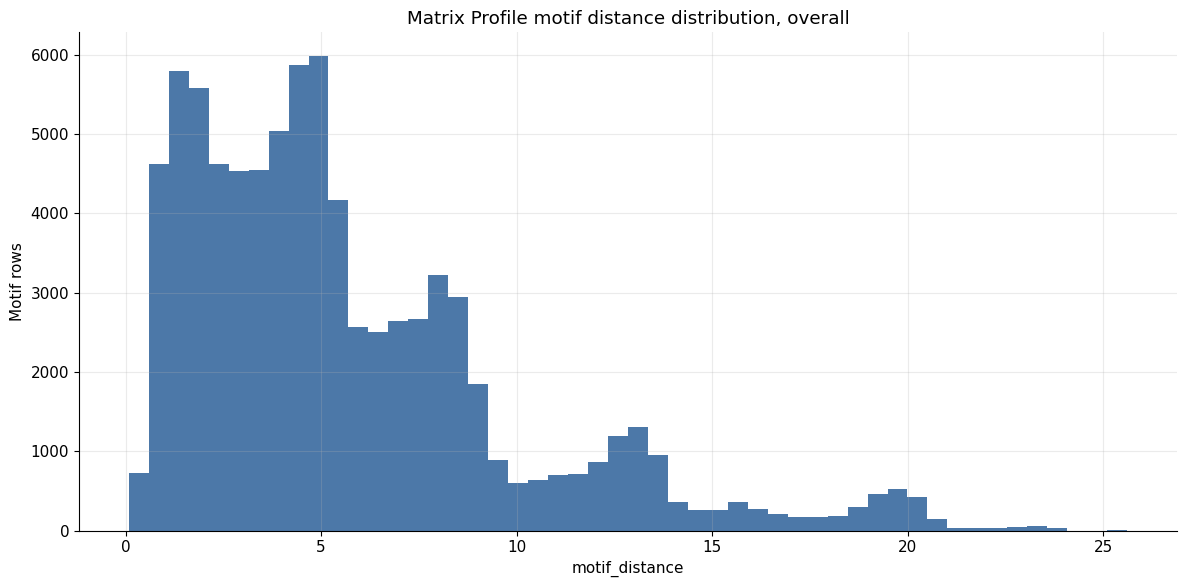

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_mode.pdf


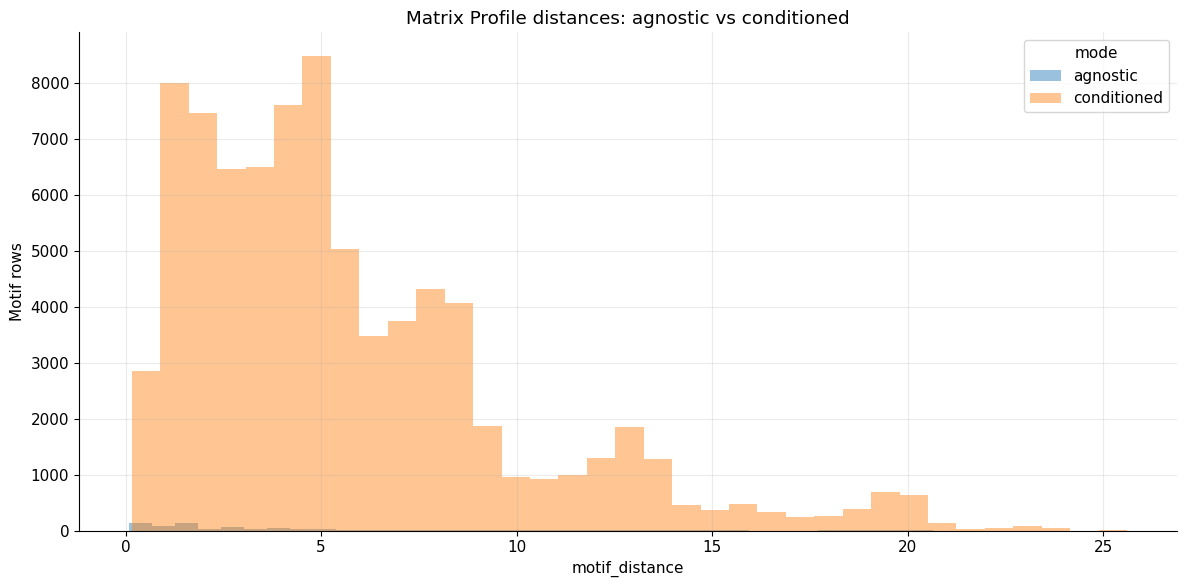

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_regime_label.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_regime_label.pdf


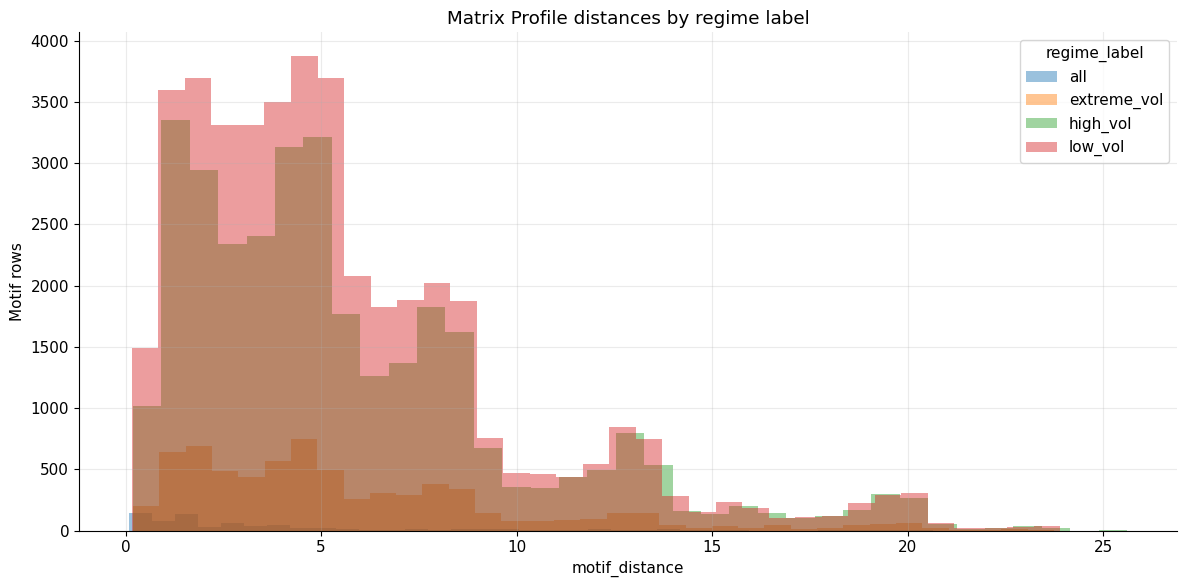

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_window_length.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_window_length.pdf


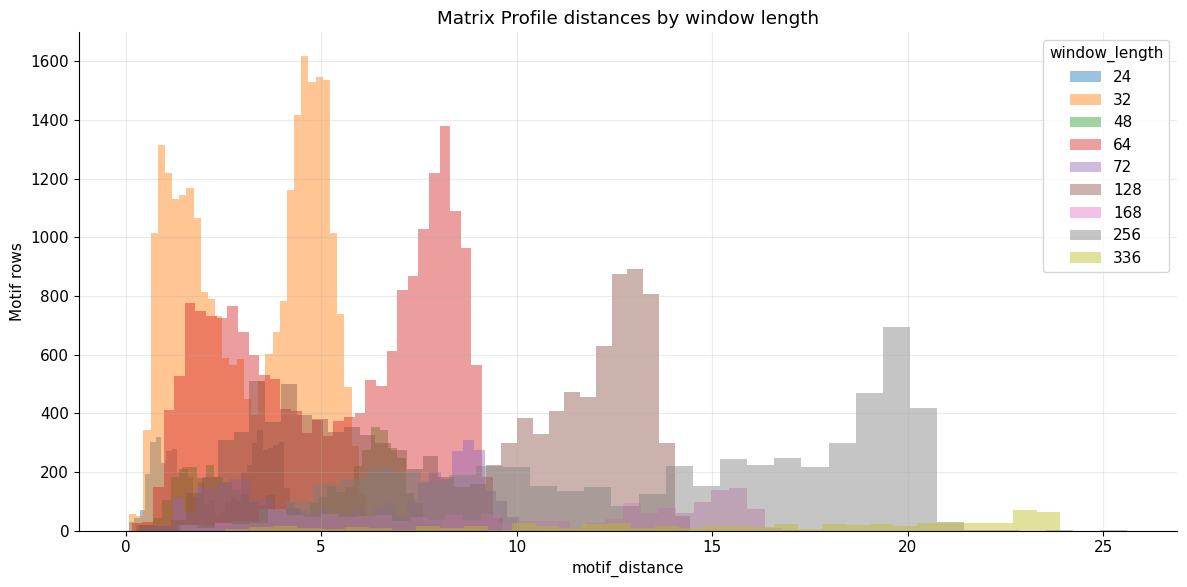

/tmp/ipykernel_3516371/2253351324.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_feature_set.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_distribution_by_feature_set.pdf


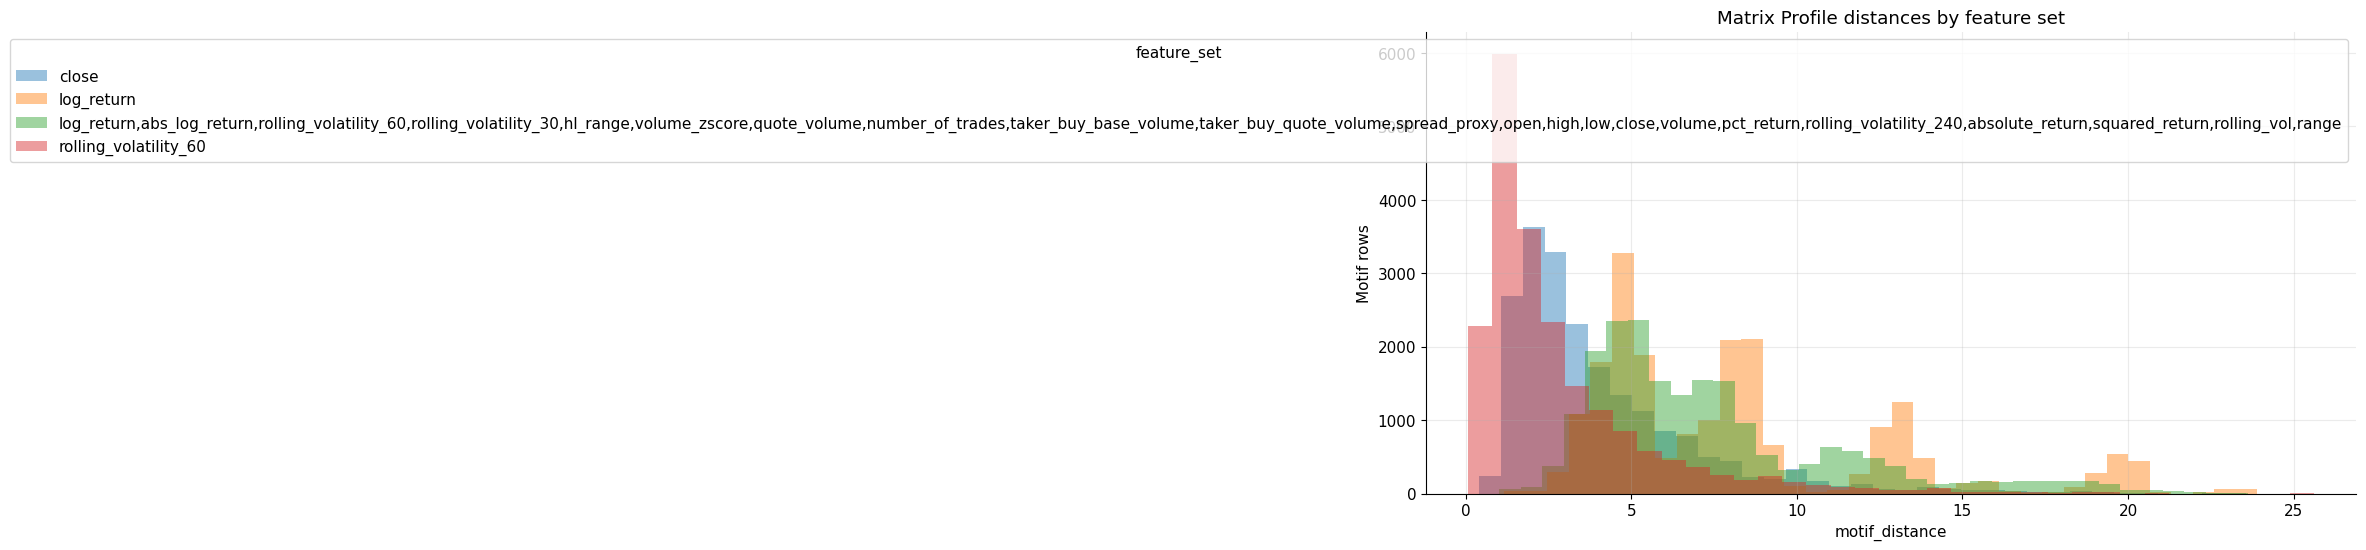

In [5]:
def plot_distance_hist(df, title, filename, by=None):
    if df.empty or not distance_col:
        print(f"No distance data for {title}")
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    if by and by in df.columns:
        for key, part in df.groupby(by, dropna=False):
            values = pd.to_numeric(part[distance_col], errors="coerce").dropna()
            if len(values):
                ax.hist(values, bins=35, alpha=0.45, label=str(key), density=False)
        ax.legend(title=by)
    else:
        pd.to_numeric(df[distance_col], errors="coerce").dropna().plot(kind="hist", bins=50, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel(distance_col)
    ax.set_ylabel("Motif rows")
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["matrix_profile"])
    plt.show()

plot_distance_hist(mp, "Matrix Profile motif distance distribution, overall", "study_mp_distance_distribution_overall")
plot_distance_hist(mp, "Matrix Profile distances: agnostic vs conditioned", "study_mp_distance_distribution_by_mode", by="mode")
plot_distance_hist(mp, "Matrix Profile distances by regime label", "study_mp_distance_distribution_by_regime_label", by="regime_label")
plot_distance_hist(mp, "Matrix Profile distances by window length", "study_mp_distance_distribution_by_window_length", by="window_length")
plot_distance_hist(mp, "Matrix Profile distances by feature set", "study_mp_distance_distribution_by_feature_set", by="feature_set")


,scope,rows,q01,q05,q10,q25,median,q75,min,max
0,overall,81987,0.617853,0.988843,1.370101,2.532795,4.654666,7.675119,0.081861,25.606804
1,agnostic,720,0.110648,0.158491,0.373395,1.021906,1.890830,4.526443,0.081861,20.645949
2,conditioned,81267,0.641414,0.996680,1.381849,2.560935,4.666110,7.685618,0.159237,25.606804
3,low_vol,42609,0.582476,0.959144,1.364294,2.565198,4.660984,7.505687,0.159237,23.901965
4,high_vol,31644,0.703811,1.056327,1.395909,2.558808,4.685775,7.872059,0.189485,25.606804
5,extreme_vol,7014,0.730404,1.048635,1.397084,2.540135,4.632362,7.873090,0.189485,23.735781


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_empirical_distance_thresholds.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_threshold_lines.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_distance_threshold_lines.pdf


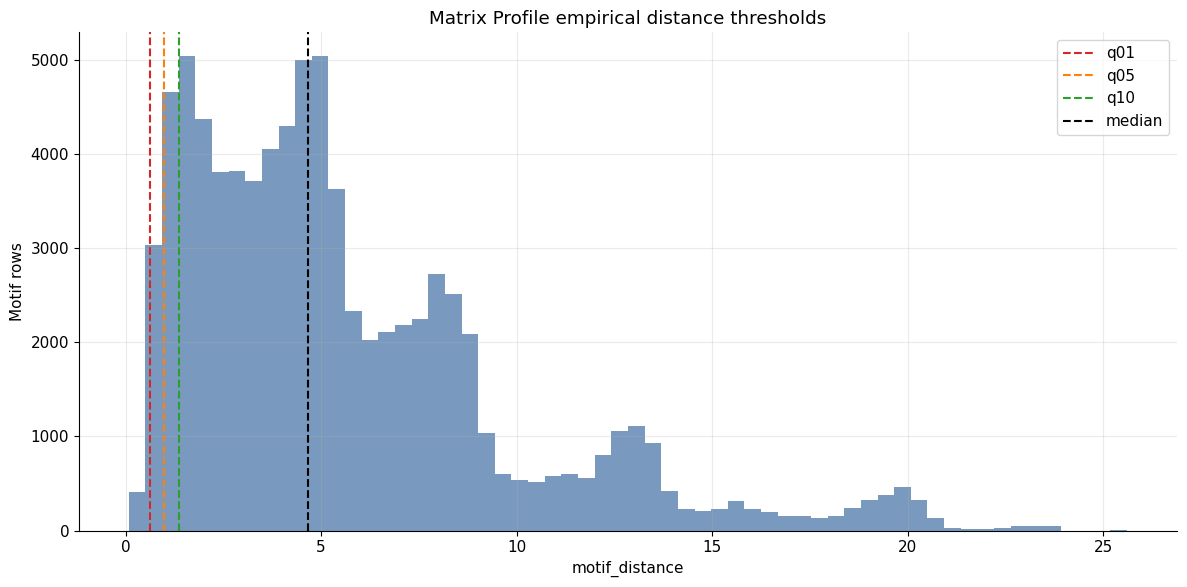

In [6]:
def threshold_record(scope, df):
    if df.empty or not distance_col:
        return {"scope": scope, "rows": len(df)}
    values = pd.to_numeric(df[distance_col], errors="coerce").dropna()
    if values.empty:
        return {"scope": scope, "rows": len(df)}
    qs = values.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75])
    return {
        "scope": scope,
        "rows": len(values),
        "q01": qs.loc[0.01],
        "q05": qs.loc[0.05],
        "q10": qs.loc[0.10],
        "q25": qs.loc[0.25],
        "median": qs.loc[0.50],
        "q75": qs.loc[0.75],
        "min": values.min(),
        "max": values.max(),
    }

scopes = [("overall", mp)]
if "mode" in mp.columns:
    scopes.extend([(str(k), v) for k, v in mp.groupby("mode", dropna=False)])
if "regime_label" in mp.columns:
    for label in ["low_vol", "high_vol", "extreme_vol"]:
        scopes.append((label, mp[mp["regime_label"].astype(str).eq(label)]))

thresholds = pd.DataFrame([threshold_record(name, df) for name, df in scopes])
display_table(thresholds, 20)
save_table(thresholds, "study_mp_empirical_distance_thresholds")

if not mp.empty and distance_col:
    values = pd.to_numeric(mp[distance_col], errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(values, bins=60, color="#4C78A8", alpha=0.75)
    overall = thresholds[thresholds["scope"].eq("overall")]
    for col, color in [("q01", "#D62728"), ("q05", "#FF7F0E"), ("q10", "#2CA02C"), ("median", "#000000")]:
        if col in overall.columns and not overall[col].isna().all():
            val = overall[col].iloc[0]
            ax.axvline(val, color=color, linestyle="--", linewidth=1.5, label=col)
    ax.set_title("Matrix Profile empirical distance thresholds")
    ax.set_xlabel(distance_col)
    ax.set_ylabel("Motif rows")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "study_mp_distance_threshold_lines", FIGURE_DIRS["matrix_profile"])
    plt.show()


### Interpretation
Matrix Profile distances are lower-is-better for the selected distance column. Matrix Profile does not provide one universal intrinsic motif threshold, so this notebook reports empirical thresholds from the observed result distribution: top 1%, top 5%, top 10%, quartiles, median, minimum, and maximum.


## Top 10 and Top 20 Motifs


In [7]:
top_cols_preferred = [
    "asset", "frequency", "mode", "regime_method", "regime_label", "feature_set", "profile_type",
    "window_length", "motif_rank", "motif_start_1", "motif_start_2", "motif_timestamp_1",
    "motif_timestamp_2", "segment_id", "used_gpu",
]
if distance_col:
    top_cols_preferred.insert(-2, distance_col)
top_cols = [c for c in top_cols_preferred if c in mp.columns]

def top_table(df, n, name):
    if df.empty or not distance_col:
        print(f"No top table for {name}")
        return pd.DataFrame()
    out = df.sort_values(distance_col, ascending=True).head(n)[top_cols].copy()
    save_table(out, name)
    display_table(out, n)
    return out

top10_overall = top_table(mp, 10, "study_mp_top10_overall")
top20_overall = top_table(mp, 20, "study_mp_top20_overall")
top10_agnostic = top_table(mp[mp["mode"].astype(str).eq("agnostic")] if "mode" in mp.columns else pd.DataFrame(), 10, "study_mp_top10_agnostic")
top10_conditioned = top_table(mp[mp["mode"].astype(str).eq("conditioned")] if "mode" in mp.columns else pd.DataFrame(), 10, "study_mp_top10_conditioned")
for label in ["low_vol", "high_vol", "extreme_vol"]:
    subset = mp[mp["regime_label"].astype(str).eq(label)] if "regime_label" in mp.columns else pd.DataFrame()
    top_table(subset, 10, f"study_mp_top10_{label}")
for asset in ["BTCUSDT", "ETHUSDT"]:
    subset = mp[(mp["asset"].astype(str).eq(asset)) & (mp["frequency"].astype(str).eq("15m"))] if {"asset", "frequency"}.issubset(mp.columns) else pd.DataFrame()
    top_table(subset, 10, f"study_mp_top10_{asset}_15m")


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top10_overall.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,profile_type,window_length,motif_rank,motif_start_1,motif_start_2,motif_timestamp_1,motif_timestamp_2,motif_distance,segment_id,used_gpu
30813,BTCUSDT,1h,agnostic,none,all,rolling_volatility_60,univariate,24,1,1692,5113,2020-03-11 19:00:00+00:00,2020-08-01 13:00:00+00:00,0.081861,full_series,False
39926,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,126827,131352,2023-08-15 16:45:00+00:00,2023-10-01 20:00:00+00:00,0.086186,full_series,False
20,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,131346,1757,2023-10-01 18:30:00+00:00,2020-01-19 07:15:00+00:00,0.090549,full_series,False
39927,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,12429,19511,2020-05-09 22:30:00+00:00,2020-07-22 20:30:00+00:00,0.091310,full_series,False
21,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,21326,138128,2020-08-10 18:15:00+00:00,2023-12-11 10:00:00+00:00,0.091651,full_series,False
39928,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,12468,1804,2020-05-10 08:15:00+00:00,2020-01-19 19:00:00+00:00,0.104497,full_series,False
39929,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,4,131334,153594,2023-10-01 15:30:00+00:00,2024-05-20 12:30:00+00:00,0.104829,full_series,False
39930,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,5,14747,106364,2020-06-03 02:00:00+00:00,2023-01-14 11:45:00+00:00,0.110525,full_series,False
74157,ETHUSDT,1h,agnostic,none,all,rolling_volatility_60,univariate,24,1,30223,34525,2023-06-14 14:00:00+00:00,2023-12-10 20:00:00+00:00,0.111174,full_series,False
22,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,20540,124724,2020-08-02 13:45:00+00:00,2023-07-24 19:00:00+00:00,0.112649,full_series,False


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top20_overall.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,profile_type,window_length,motif_rank,motif_start_1,motif_start_2,motif_timestamp_1,motif_timestamp_2,motif_distance,segment_id,used_gpu
30813,BTCUSDT,1h,agnostic,none,all,rolling_volatility_60,univariate,24,1,1692,5113,2020-03-11 19:00:00+00:00,2020-08-01 13:00:00+00:00,0.081861,full_series,False
39926,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,126827,131352,2023-08-15 16:45:00+00:00,2023-10-01 20:00:00+00:00,0.086186,full_series,False
20,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,131346,1757,2023-10-01 18:30:00+00:00,2020-01-19 07:15:00+00:00,0.090549,full_series,False
39927,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,12429,19511,2020-05-09 22:30:00+00:00,2020-07-22 20:30:00+00:00,0.091310,full_series,False
21,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,21326,138128,2020-08-10 18:15:00+00:00,2023-12-11 10:00:00+00:00,0.091651,full_series,False
39928,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,12468,1804,2020-05-10 08:15:00+00:00,2020-01-19 19:00:00+00:00,0.104497,full_series,False
39929,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,4,131334,153594,2023-10-01 15:30:00+00:00,2024-05-20 12:30:00+00:00,0.104829,full_series,False
39930,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,5,14747,106364,2020-06-03 02:00:00+00:00,2023-01-14 11:45:00+00:00,0.110525,full_series,False
74157,ETHUSDT,1h,agnostic,none,all,rolling_volatility_60,univariate,24,1,30223,34525,2023-06-14 14:00:00+00:00,2023-12-10 20:00:00+00:00,0.111174,full_series,False
22,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,20540,124724,2020-08-02 13:45:00+00:00,2023-07-24 19:00:00+00:00,0.112649,full_series,False


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top10_agnostic.csv


...

,asset,frequency,mode,regime_method,regime_label,feature_set,profile_type,window_length,motif_rank,motif_start_1,motif_start_2,motif_timestamp_1,motif_timestamp_2,motif_distance,segment_id,used_gpu
38322,BTCUSDT,1h,conditioned,quantile_4_rolling_240,extreme_vol,rolling_volatility_60,univariate,24,1,630,874,2021-01-28 18:00:00+00:00,2021-02-07 22:00:00+00:00,0.189485,extreme_vol_0002,False
38889,BTCUSDT,1h,conditioned,quantile_4_rolling_30,extreme_vol,rolling_volatility_60,univariate,24,1,630,874,2021-01-28 18:00:00+00:00,2021-02-07 22:00:00+00:00,0.189485,extreme_vol_0002,False
39456,BTCUSDT,1h,conditioned,quantile_4_rolling_60,extreme_vol,rolling_volatility_60,univariate,24,1,630,874,2021-01-28 18:00:00+00:00,2021-02-07 22:00:00+00:00,0.189485,extreme_vol_0002,False
38323,BTCUSDT,1h,conditioned,quantile_4_rolling_240,extreme_vol,rolling_volatility_60,univariate,24,2,936,692,2021-02-10 12:00:00+00:00,2021-01-31 08:00:00+00:00,0.342829,extreme_vol_0002,False
38890,BTCUSDT,1h,conditioned,quantile_4_rolling_30,extreme_vol,rolling_volatility_60,univariate,24,2,936,692,2021-02-10 12:00:00+00:00,2021-01-31 08:00:00+00:00,0.342829,extreme_vol_0002,False
39457,BTCUSDT,1h,conditioned,quantile_4_rolling_60,extreme_vol,rolling_volatility_60,univariate,24,2,936,692,2021-02-10 12:00:00+00:00,2021-01-31 08:00:00+00:00,0.342829,extreme_vol_0002,False
39025,BTCUSDT,1h,conditioned,quantile_4_rolling_30,extreme_vol,rolling_volatility_60,univariate,24,1,731,629,2021-06-08 23:00:00+00:00,2021-06-04 17:00:00+00:00,0.503997,extreme_vol_0003,False
38458,BTCUSDT,1h,conditioned,quantile_4_rolling_240,extreme_vol,rolling_volatility_60,univariate,24,1,731,629,2021-06-08 23:00:00+00:00,2021-06-04 17:00:00+00:00,0.503997,extreme_vol_0003,False
39592,BTCUSDT,1h,conditioned,quantile_4_rolling_60,extreme_vol,rolling_volatility_60,univariate,24,1,731,629,2021-06-08 23:00:00+00:00,2021-06-04 17:00:00+00:00,0.503997,extreme_vol_0003,False
38324,BTCUSDT,1h,conditioned,quantile_4_rolling_240,extreme_vol,rolling_volatility_60,univariate,24,3,37,211,2021-01-04 01:00:00+00:00,2021-01-11 07:00:00+00:00,0.515118,extreme_vol_0002,False


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top10_BTCUSDT_15m.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,profile_type,window_length,motif_rank,motif_start_1,motif_start_2,motif_timestamp_1,motif_timestamp_2,motif_distance,segment_id,used_gpu
20,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,131346,1757,2023-10-01 18:30:00+00:00,2020-01-19 07:15:00+00:00,0.090549,full_series,False
21,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,21326,138128,2020-08-10 18:15:00+00:00,2023-12-11 10:00:00+00:00,0.091651,full_series,False
22,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,20540,124724,2020-08-02 13:45:00+00:00,2023-07-24 19:00:00+00:00,0.112649,full_series,False
23,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,4,14731,132794,2020-06-02 22:00:00+00:00,2023-10-16 20:30:00+00:00,0.120386,full_series,False
24,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,5,27149,12468,2020-10-10 10:00:00+00:00,2020-05-10 08:15:00+00:00,0.124808,full_series,False
25,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,6,12416,19343,2020-05-09 19:15:00+00:00,2020-07-21 02:30:00+00:00,0.131790,full_series,False
26,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,7,78306,137335,2022-03-28 05:15:00+00:00,2023-12-03 03:45:00+00:00,0.138432,full_series,False
27,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,8,119161,133457,2023-05-27 20:15:00+00:00,2023-10-23 18:15:00+00:00,0.151095,full_series,False
28,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,9,93946,94600,2022-09-07 03:15:00+00:00,2022-09-13 22:45:00+00:00,0.151710,full_series,False
29,BTCUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,10,94551,66062,2022-09-13 10:30:00+00:00,2021-11-20 16:15:00+00:00,0.154110,full_series,False


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top10_ETHUSDT_15m.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,profile_type,window_length,motif_rank,motif_start_1,motif_start_2,motif_timestamp_1,motif_timestamp_2,motif_distance,segment_id,used_gpu
39926,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,1,126827,131352,2023-08-15 16:45:00+00:00,2023-10-01 20:00:00+00:00,0.086186,full_series,False
39927,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,2,12429,19511,2020-05-09 22:30:00+00:00,2020-07-22 20:30:00+00:00,0.091310,full_series,False
39928,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,3,12468,1804,2020-05-10 08:15:00+00:00,2020-01-19 19:00:00+00:00,0.104497,full_series,False
39929,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,4,131334,153594,2023-10-01 15:30:00+00:00,2024-05-20 12:30:00+00:00,0.104829,full_series,False
39930,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,5,14747,106364,2020-06-03 02:00:00+00:00,2023-01-14 11:45:00+00:00,0.110525,full_series,False
39931,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,6,179351,108133,2025-02-12 19:45:00+00:00,2023-02-01 22:00:00+00:00,0.121663,full_series,False
39932,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,7,125412,106307,2023-07-31 23:00:00+00:00,2023-01-13 21:30:00+00:00,0.131759,full_series,False
39933,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,8,119295,140375,2023-05-29 05:45:00+00:00,2024-01-03 19:45:00+00:00,0.133875,full_series,False
39934,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,9,131391,124579,2023-10-02 05:45:00+00:00,2023-07-23 06:45:00+00:00,0.136185,full_series,False
39935,ETHUSDT,15m,agnostic,none,all,rolling_volatility_60,univariate,32,10,94002,101987,2022-09-07 17:15:00+00:00,2022-11-29 21:30:00+00:00,0.142798,full_series,False


## Top Motif Overlay Plots


Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_1_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_1_BTCUSDT_1h_rolling_volatility_60_w24.pdf


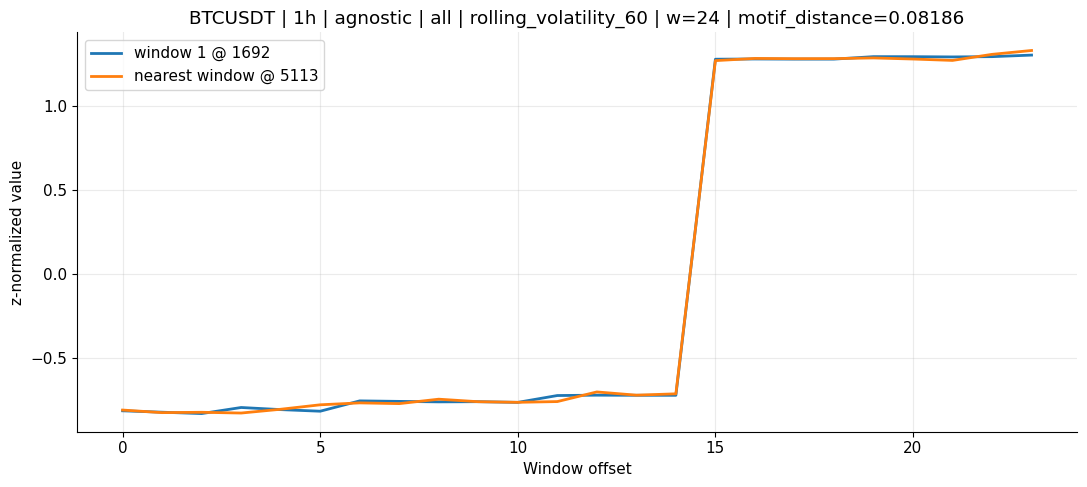

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_2_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_2_ETHUSDT_15m_rolling_volatility_60_w32.pdf


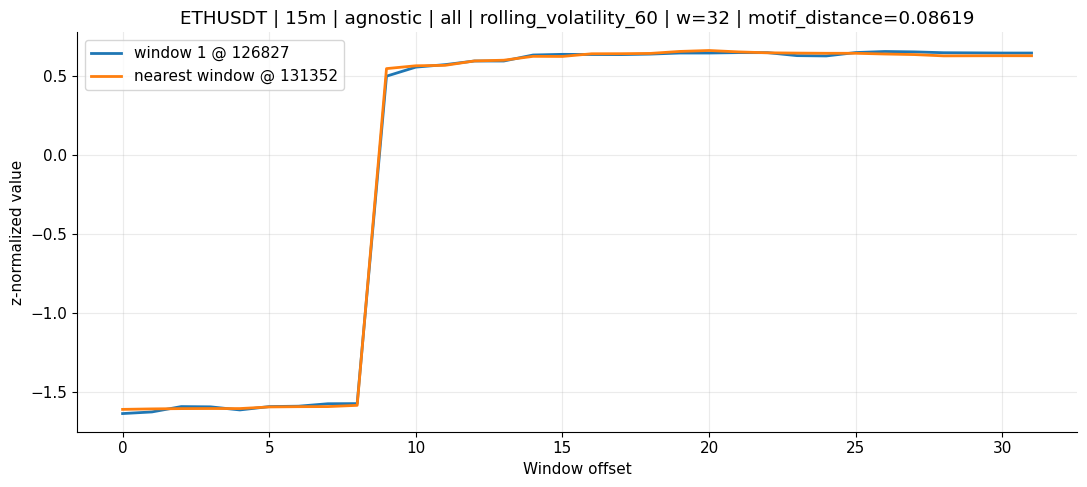

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_3_BTCUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_3_BTCUSDT_15m_rolling_volatility_60_w32.pdf


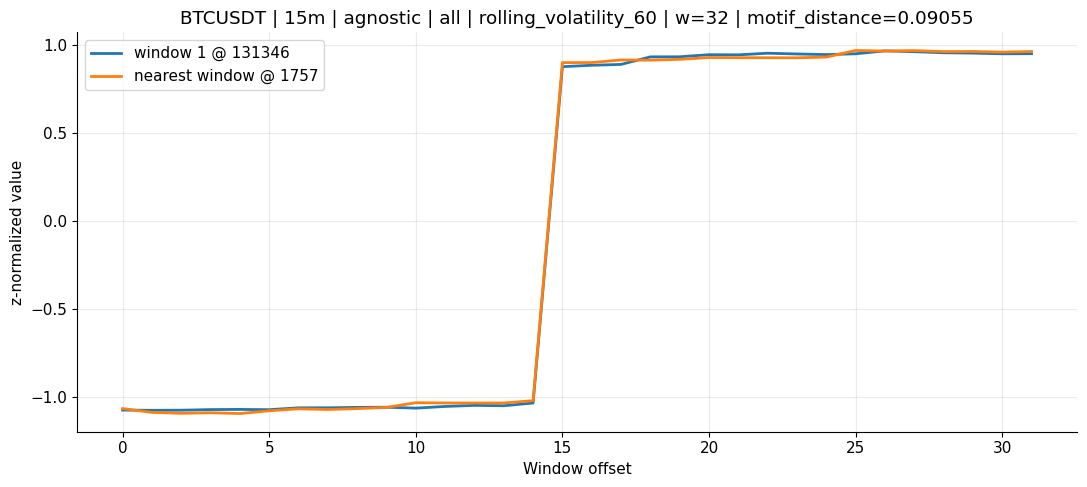

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_4_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_4_ETHUSDT_15m_rolling_volatility_60_w32.pdf


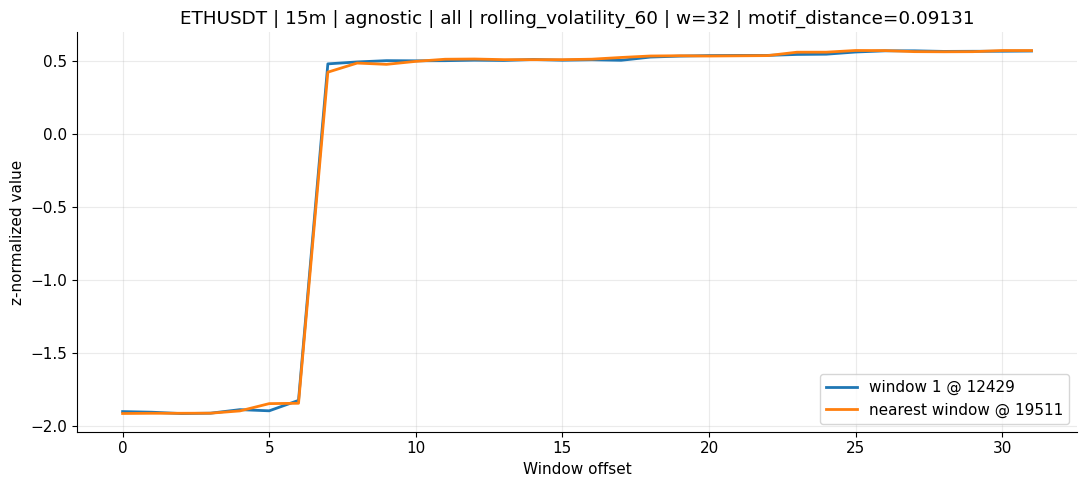

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_5_BTCUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_overall_5_BTCUSDT_15m_rolling_volatility_60_w32.pdf


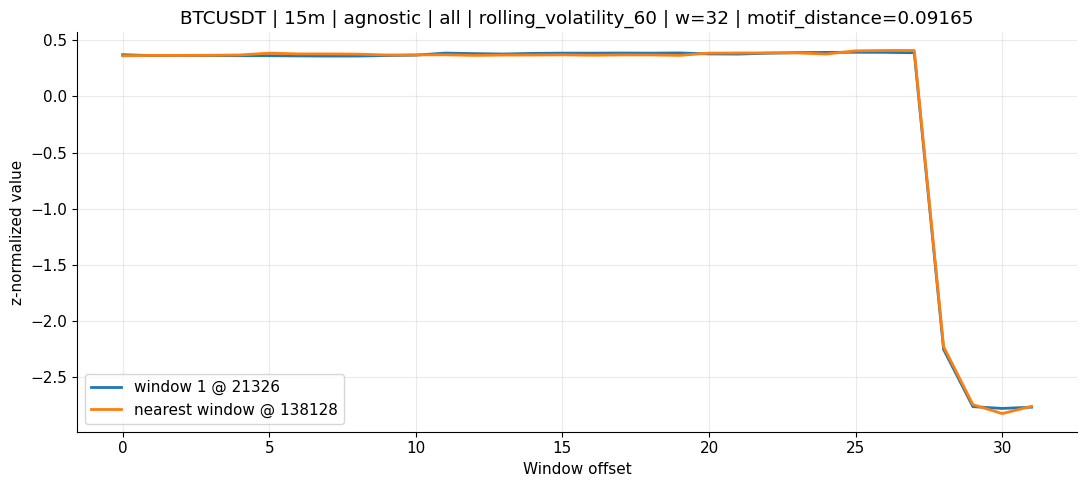

top5_overall: created 5 overlay plots.
Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_1_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_1_BTCUSDT_1h_rolling_volatility_60_w24.pdf


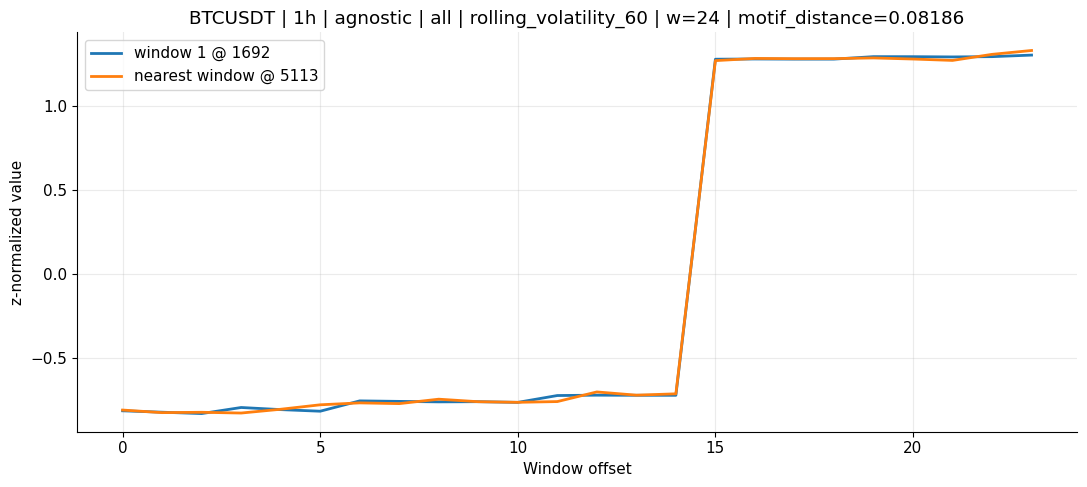

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_2_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_2_ETHUSDT_15m_rolling_volatility_60_w32.pdf


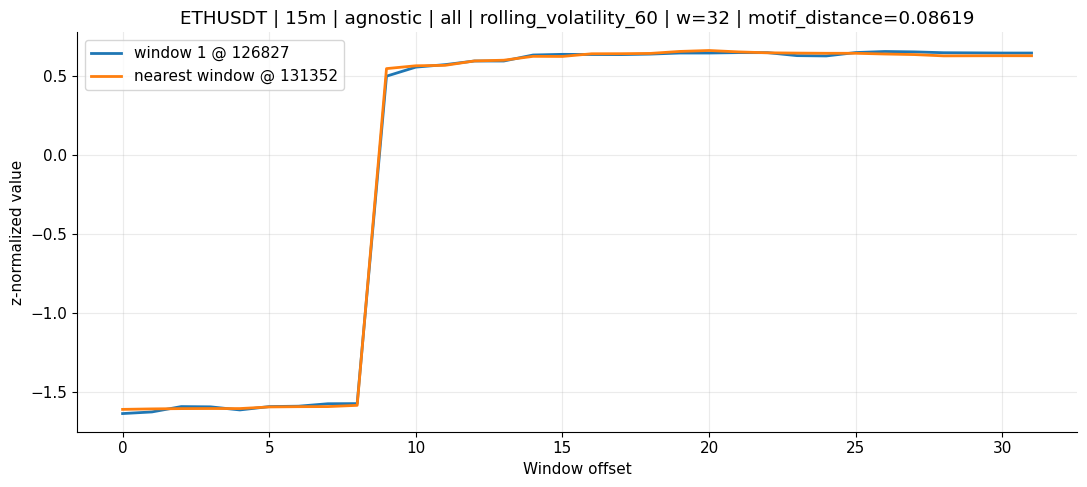

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_3_BTCUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_3_BTCUSDT_15m_rolling_volatility_60_w32.pdf


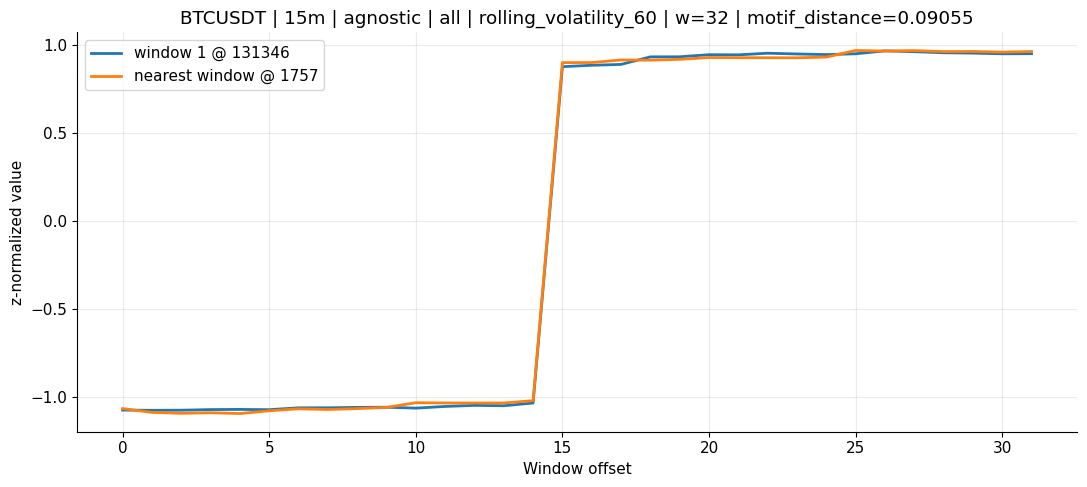

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_4_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_4_ETHUSDT_15m_rolling_volatility_60_w32.pdf


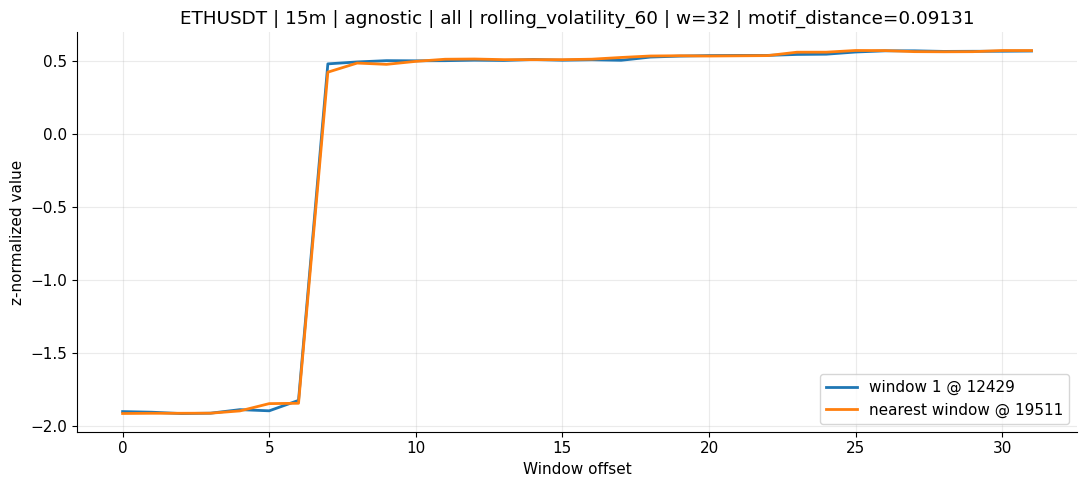

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_5_BTCUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_agnostic_5_BTCUSDT_15m_rolling_volatility_60_w32.pdf


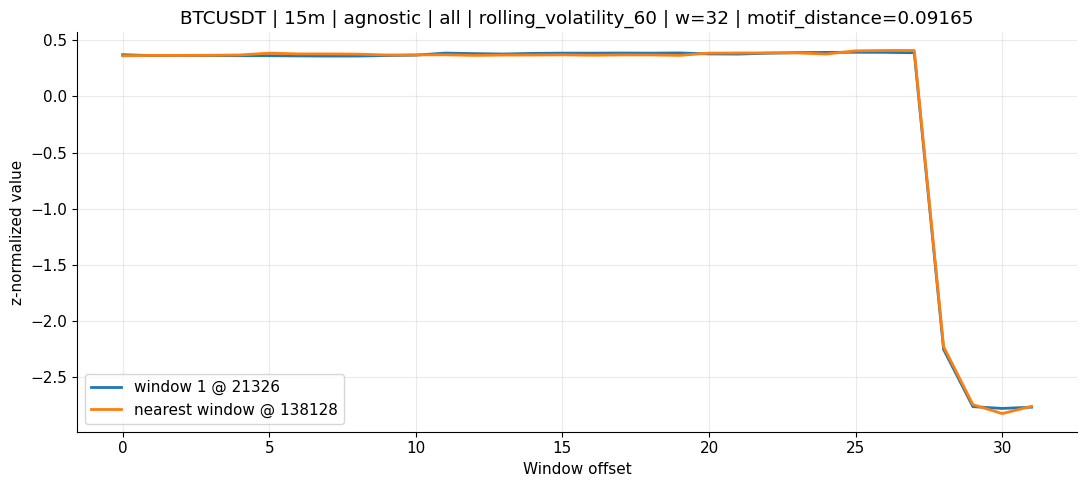

top5_agnostic: created 5 overlay plots.
Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_1_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_1_ETHUSDT_15m_rolling_volatility_60_w32.pdf


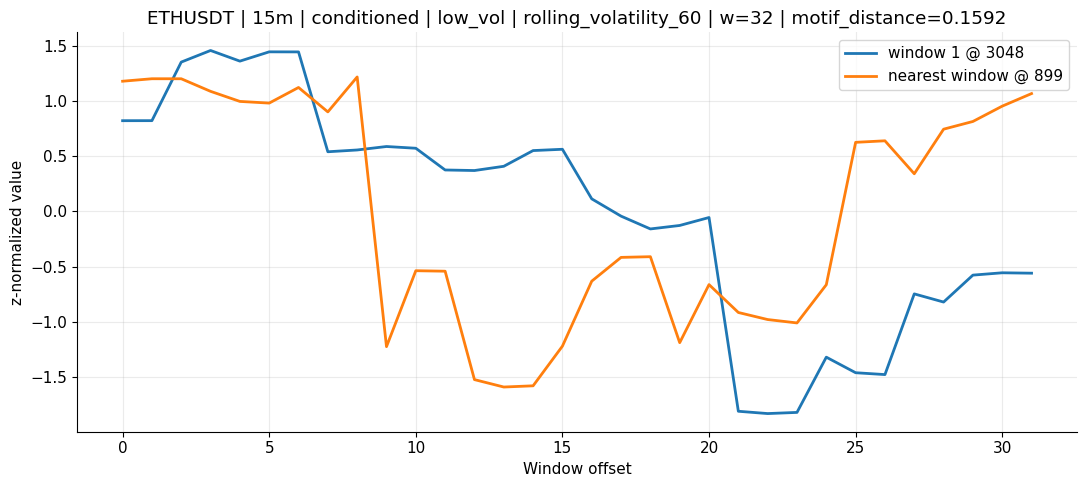

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_2_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_2_ETHUSDT_15m_rolling_volatility_60_w32.pdf


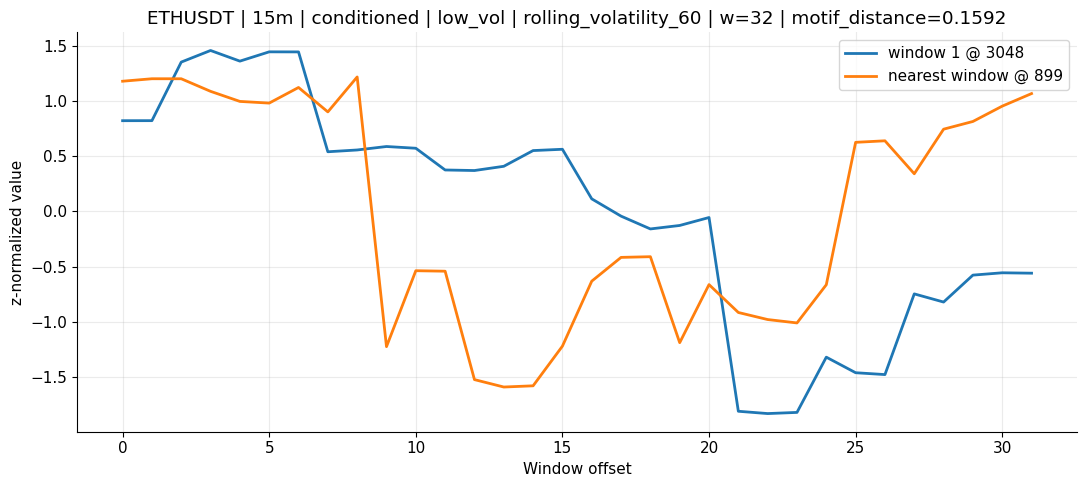

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_3_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_3_ETHUSDT_15m_rolling_volatility_60_w32.pdf


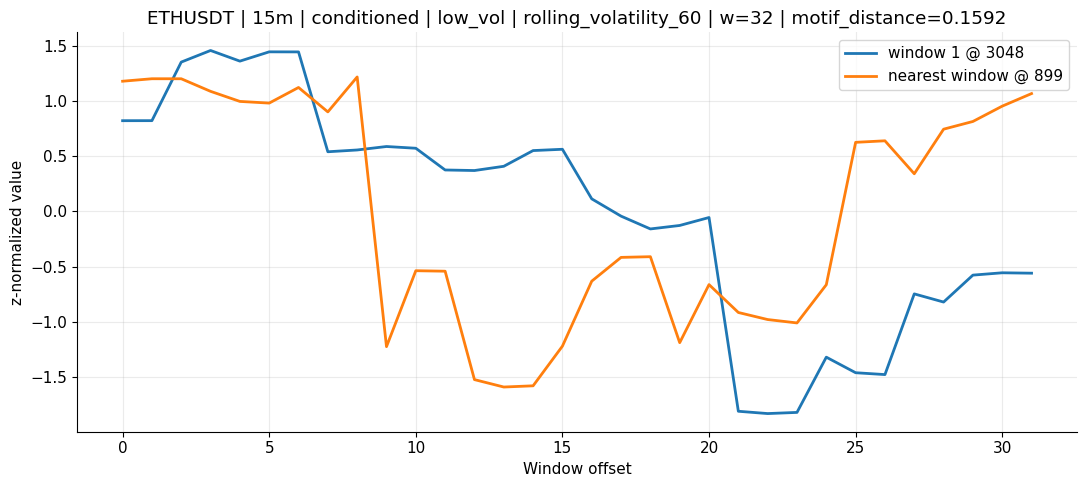

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_4_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_4_ETHUSDT_15m_rolling_volatility_60_w32.pdf


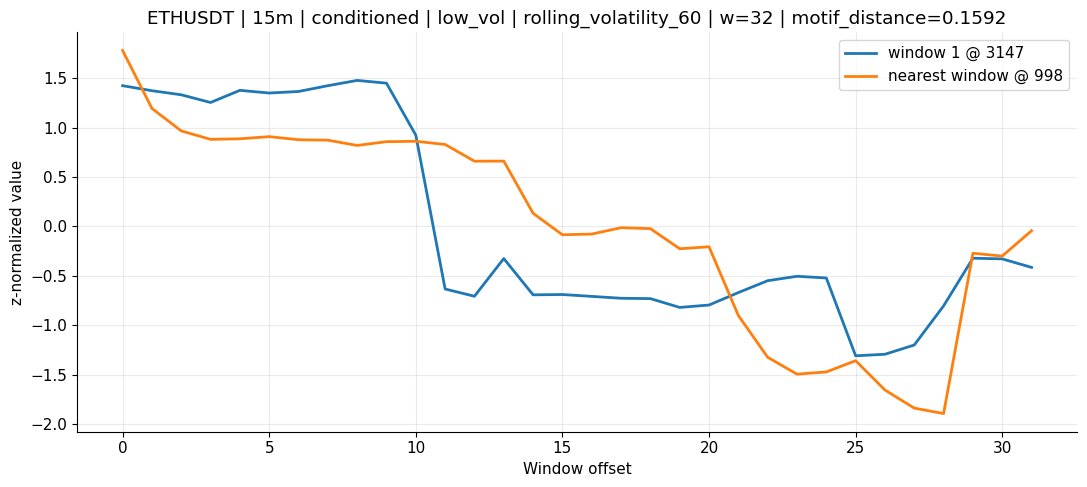

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_5_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_conditioned_5_ETHUSDT_15m_rolling_volatility_60_w32.pdf


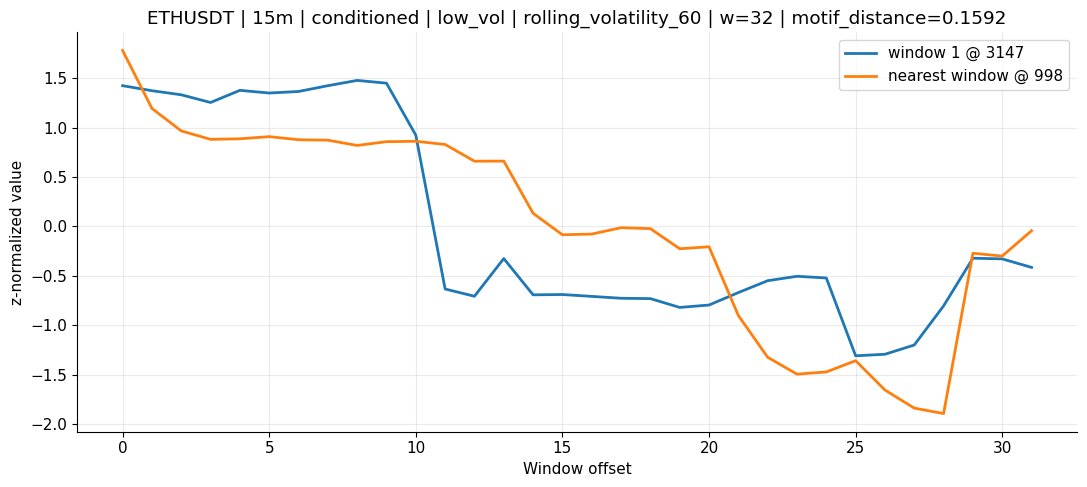

top5_conditioned: created 5 overlay plots.
Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_1_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_1_BTCUSDT_1h_rolling_volatility_60_w24.pdf


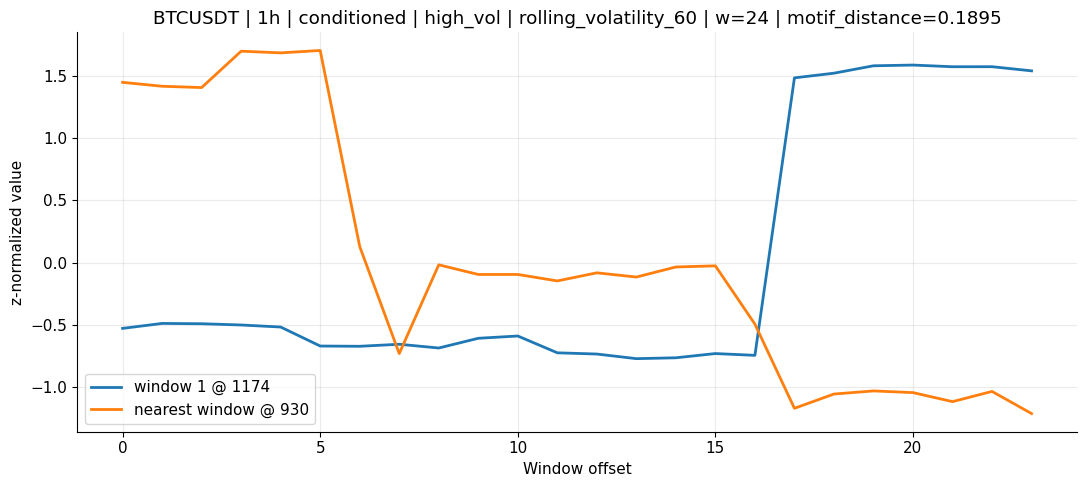

Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_2_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_2_BTCUSDT_1h_rolling_volatility_60_w24.pdf


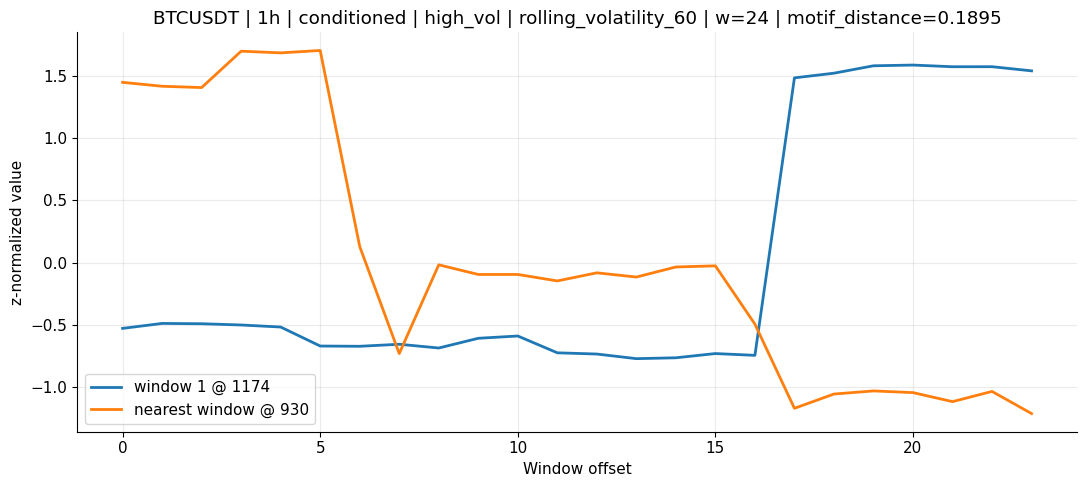

Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_3_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_3_BTCUSDT_1h_rolling_volatility_60_w24.pdf


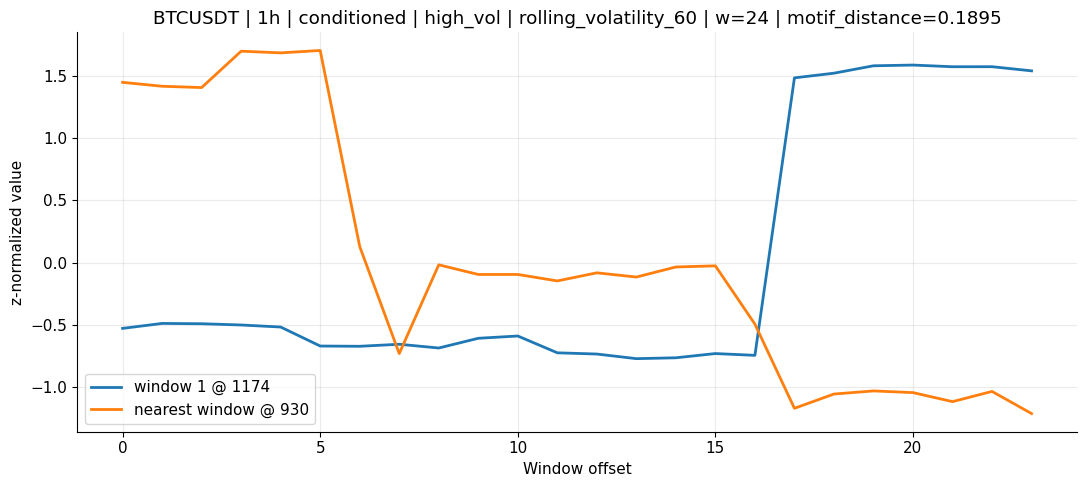

Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_4_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_4_BTCUSDT_1h_rolling_volatility_60_w24.pdf


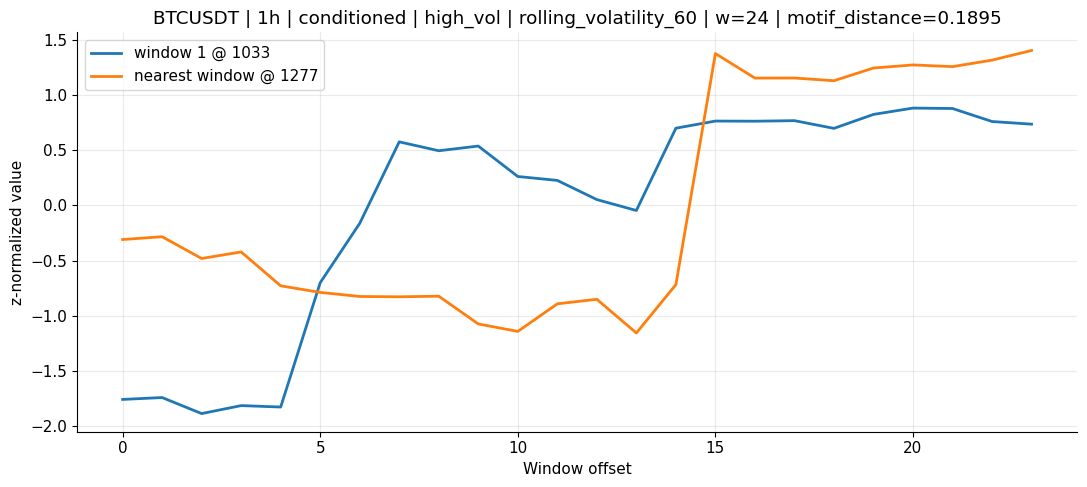

Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_5_BTCUSDT_1h_rolling_volatility_60_w24.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_high_vol_5_BTCUSDT_1h_rolling_volatility_60_w24.pdf


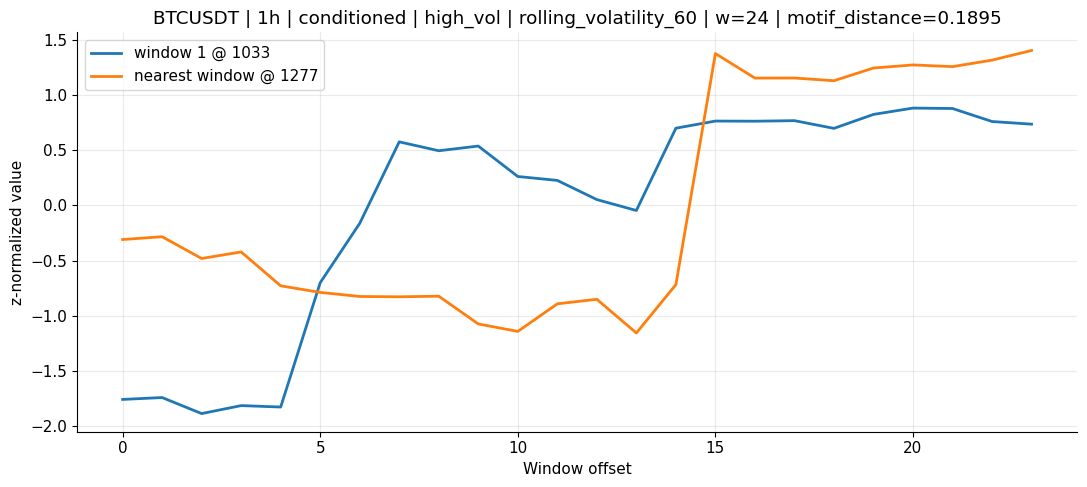

top5_high_vol: created 5 overlay plots.
Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_1_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_1_ETHUSDT_15m_rolling_volatility_60_w32.pdf


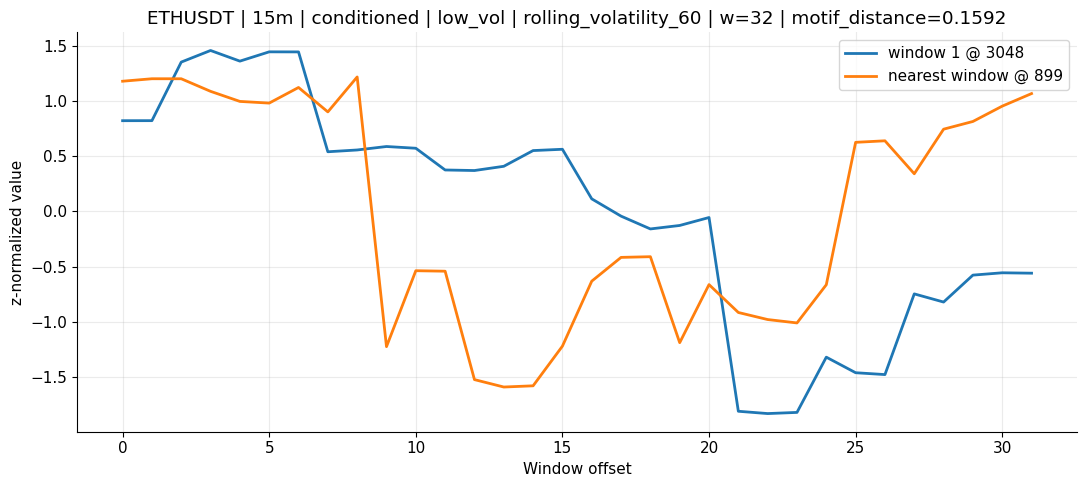

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_2_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_2_ETHUSDT_15m_rolling_volatility_60_w32.pdf


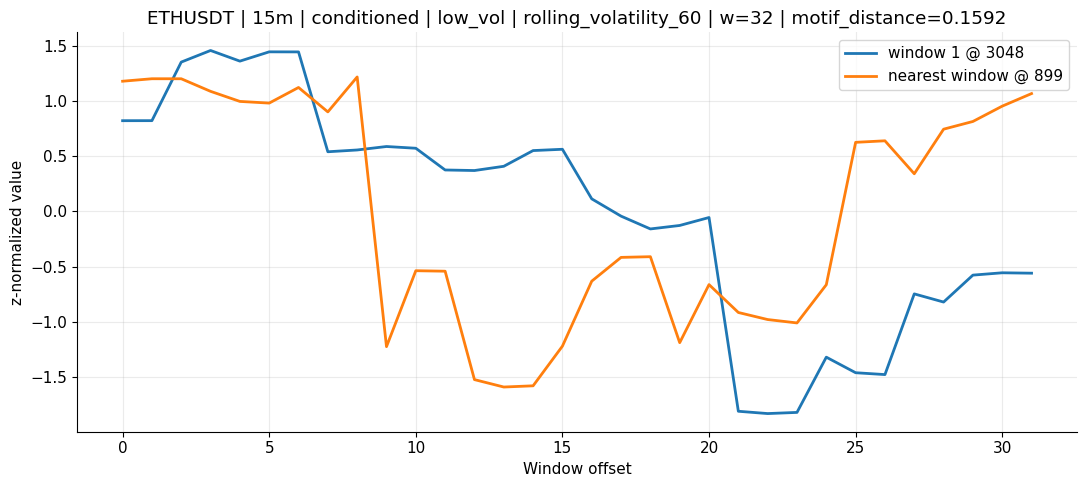

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_3_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_3_ETHUSDT_15m_rolling_volatility_60_w32.pdf


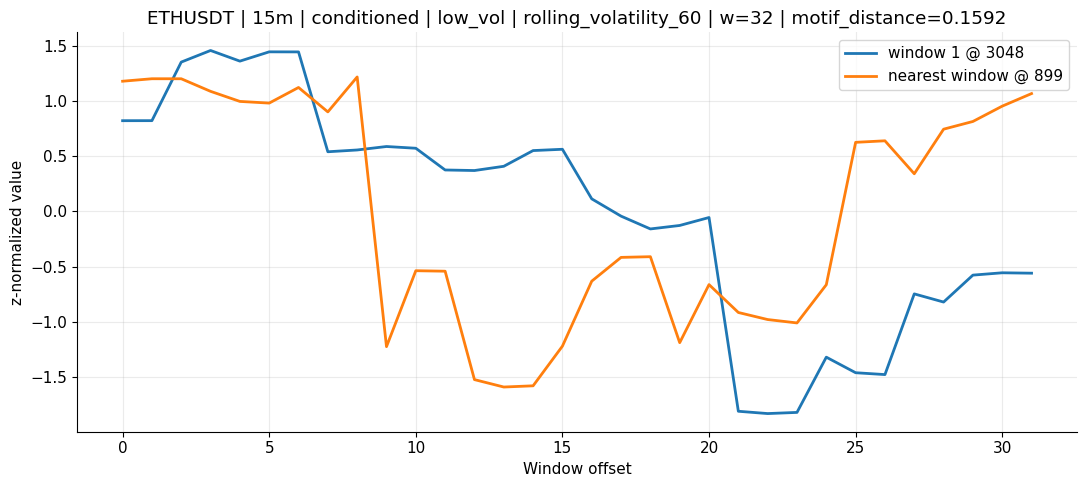

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_4_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_4_ETHUSDT_15m_rolling_volatility_60_w32.pdf


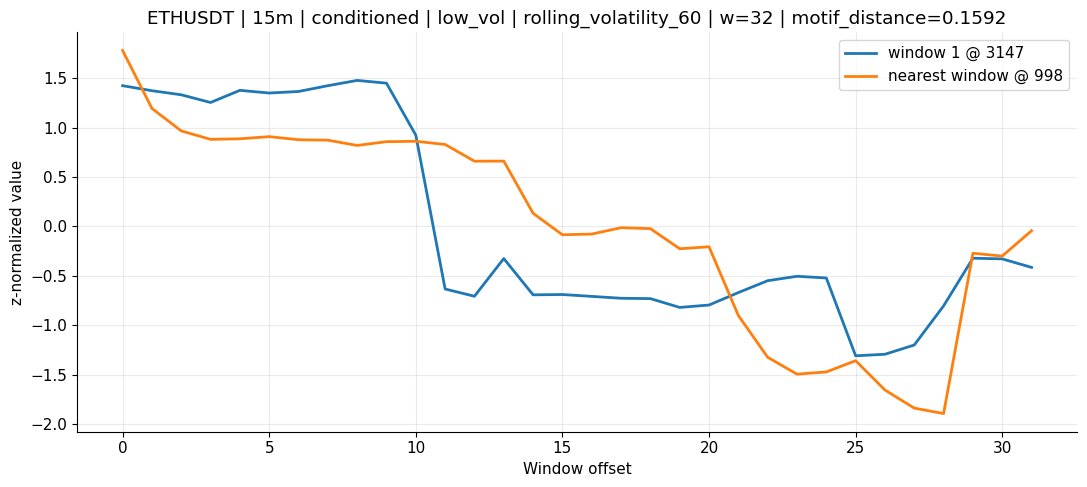

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_5_ETHUSDT_15m_rolling_volatility_60_w32.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_overlay_top5_low_vol_5_ETHUSDT_15m_rolling_volatility_60_w32.pdf


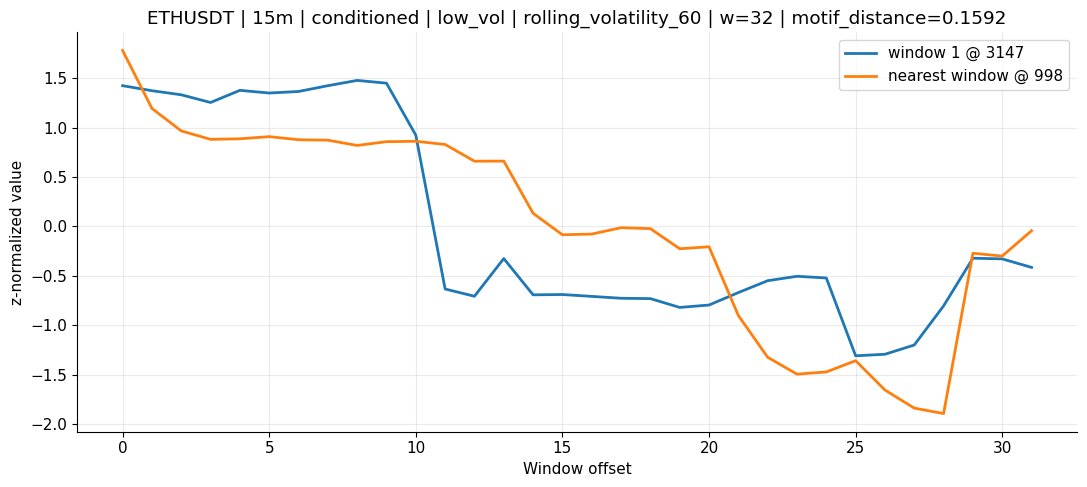

top5_low_vol: created 5 overlay plots.


In [8]:
def plot_motif_overlay(row, filename):
    asset = str(row.get("asset", ""))
    frequency = str(row.get("frequency", ""))
    feature_set = str(row.get("feature_set", "close"))
    window = int(row.get("window_length", 0)) if pd.notna(row.get("window_length", np.nan)) else 0
    s1 = int(row.get("motif_start_1", -1)) if pd.notna(row.get("motif_start_1", np.nan)) else -1
    s2 = int(row.get("motif_start_2", -1)) if pd.notna(row.get("motif_start_2", np.nan)) else -1
    if window <= 1 or s1 < 0 or s2 < 0:
        print("Cannot plot overlay: missing start indices or window length.")
        return False
    feature = load_feature_data(asset, frequency)
    value_col = find_feature_value_column(feature, feature_set)
    if feature.empty or not value_col:
        print(f"Cannot plot overlay for {asset} {frequency}: feature column unavailable.")
        return False
    if s1 + window > len(feature) or s2 + window > len(feature):
        print(f"Cannot plot overlay for {asset} {frequency}: motif windows exceed feature length.")
        return False
    y1 = z_normalize(feature[value_col].iloc[s1:s1 + window])
    y2 = z_normalize(feature[value_col].iloc[s2:s2 + window])
    x = np.arange(window)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(x, y1, label=f"window 1 @ {s1}", linewidth=2.0, color="#1F77B4")
    ax.plot(x, y2, label=f"nearest window @ {s2}", linewidth=2.0, color="#FF7F0E")
    dist_text = f"{distance_col}={row.get(distance_col):.4g}" if distance_col and pd.notna(row.get(distance_col, np.nan)) else "distance unavailable"
    title_bits = [asset, frequency, str(row.get("mode", "")), str(row.get("regime_label", "")), value_col, f"w={window}", dist_text]
    ax.set_title(" | ".join([b for b in title_bits if b and b != "nan"]))
    ax.set_xlabel("Window offset")
    ax.set_ylabel("z-normalized value")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["matrix_profile"])
    plt.show()
    return True

def overlay_batch(df, label, n=5):
    if df.empty or not distance_col:
        print(f"No rows available for overlay batch: {label}")
        return
    selected = df.sort_values(distance_col, ascending=True).head(n)
    successes = 0
    for idx, row in selected.iterrows():
        name = f"study_mp_overlay_{label}_{successes + 1}_{row.get('asset','asset')}_{row.get('frequency','freq')}_{row.get('feature_set','feature')}_w{row.get('window_length','w')}"
        successes += int(plot_motif_overlay(row, name))
    print(f"{label}: created {successes} overlay plots.")

overlay_batch(mp, "top5_overall")
if "mode" in mp.columns:
    overlay_batch(mp[mp["mode"].astype(str).eq("agnostic")], "top5_agnostic")
    overlay_batch(mp[mp["mode"].astype(str).eq("conditioned")], "top5_conditioned")
if "regime_label" in mp.columns:
    overlay_batch(mp[mp["regime_label"].astype(str).eq("high_vol")], "top5_high_vol")
    overlay_batch(mp[mp["regime_label"].astype(str).eq("low_vol")], "top5_low_vol")


### Interpretation
Each overlay compares the motif window and its nearest-neighbour window after z-normalization. Similar shapes with low distances are candidate recurring subsequences under the selected feature, window length, and regime context.


## Matrix Profile Curves or Ranked Distance Plots


Raw matrix profile curve unavailable or not alignable; plotting ranked distances instead.


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_ranked_distance_elbow.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_ranked_distance_elbow.pdf


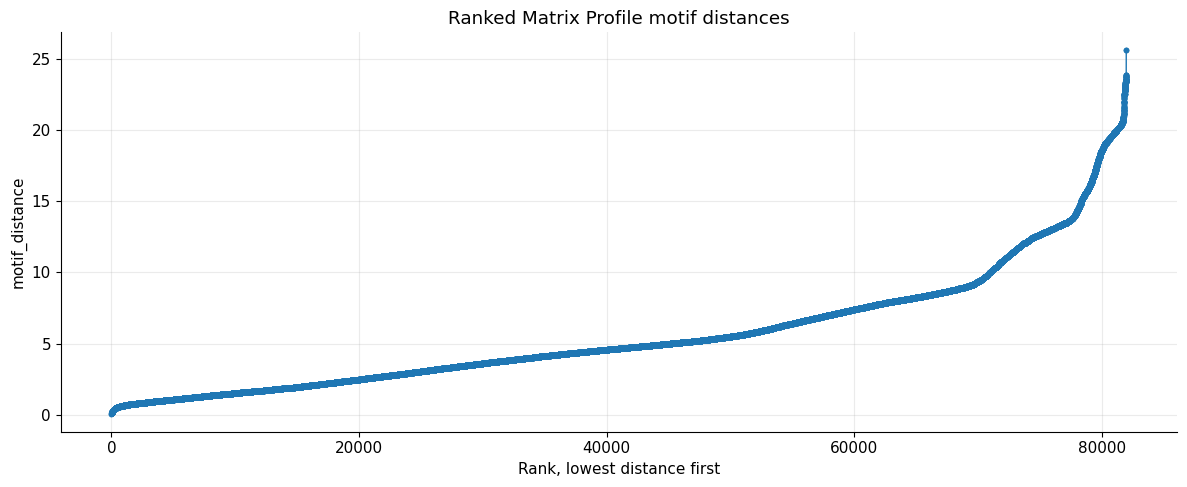

In [9]:
def plot_profile_for_top(row, filename):
    if profiles.empty:
        return False
    filters = {}
    for col in ["asset", "frequency", "mode", "regime_method", "regime_label", "segment_id", "window_length", "feature_set"]:
        if col in profiles.columns and col in row.index and pd.notna(row[col]):
            filters[col] = row[col]
    work = profiles.copy()
    for col, val in filters.items():
        work = work[work[col].astype(str) == str(val)]
    value_col = "matrix_profile" if "matrix_profile" in work.columns else find_distance_column(work)
    idx_col = "profile_index" if "profile_index" in work.columns else None
    if work.empty or not value_col:
        return False
    if len(work) > 20000:
        work = work.sample(20000, random_state=7).sort_values(idx_col) if idx_col else work.sample(20000, random_state=7)
    fig, ax = plt.subplots(figsize=(13, 5))
    x = work[idx_col] if idx_col else np.arange(len(work))
    ax.plot(x, work[value_col], color="#4C78A8", linewidth=1.0)
    for start_col, color in [("motif_start_1", "#D62728"), ("motif_start_2", "#FF7F0E")]:
        if start_col in row.index and pd.notna(row[start_col]):
            ax.axvline(float(row[start_col]), color=color, linestyle="--", label=start_col)
    if distance_col and not thresholds.empty:
        overall = thresholds[thresholds["scope"].eq("overall")]
        for q in ["q01", "q05", "q10"]:
            if q in overall.columns and not overall[q].isna().all():
                ax.axhline(overall[q].iloc[0], linestyle=":", linewidth=1.2, label=q)
    ax.set_title("Matrix Profile curve with top motif locations")
    ax.set_xlabel(idx_col or "Profile row")
    ax.set_ylabel(value_col)
    ax.legend()
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["matrix_profile"])
    plt.show()
    return True

profile_done = False
if not top10_overall.empty:
    profile_done = plot_profile_for_top(top10_overall.iloc[0], "study_mp_profile_curve_top_motif")

if not profile_done:
    print("Raw matrix profile curve unavailable or not alignable; plotting ranked distances instead.")
    if not mp.empty and distance_col:
        ranked = mp.sort_values(distance_col, ascending=True).reset_index(drop=True)
        ranked["rank"] = np.arange(1, len(ranked) + 1)
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(ranked["rank"], ranked[distance_col], marker=".", linewidth=1.0)
        ax.set_title("Ranked Matrix Profile motif distances")
        ax.set_xlabel("Rank, lowest distance first")
        ax.set_ylabel(distance_col)
        fig.tight_layout()
        save_fig(fig, "study_mp_ranked_distance_elbow", FIGURE_DIRS["matrix_profile"])
        plt.show()


## Overlapping Time Motif Illustrations


,motif_id,asset,frequency,mode,regime_label,window_length,start_1,start_2,overlap_length,overlap_ratio
0,30813,BTCUSDT,1h,agnostic,all,24,1692,5113,0,0.0
1,39926,ETHUSDT,15m,agnostic,all,32,126827,131352,0,0.0
2,20,BTCUSDT,15m,agnostic,all,32,131346,1757,0,0.0
3,39927,ETHUSDT,15m,agnostic,all,32,12429,19511,0,0.0
4,21,BTCUSDT,15m,agnostic,all,32,21326,138128,0,0.0
5,39928,ETHUSDT,15m,agnostic,all,32,12468,1804,0,0.0
6,39929,ETHUSDT,15m,agnostic,all,32,131334,153594,0,0.0
7,39930,ETHUSDT,15m,agnostic,all,32,14747,106364,0,0.0
8,74157,ETHUSDT,1h,agnostic,all,24,30223,34525,0,0.0
9,22,BTCUSDT,15m,agnostic,all,32,20540,124724,0,0.0


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_top50_motif_window_overlap.csv
Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_15m_top_motifs.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_15m_top_motifs.pdf


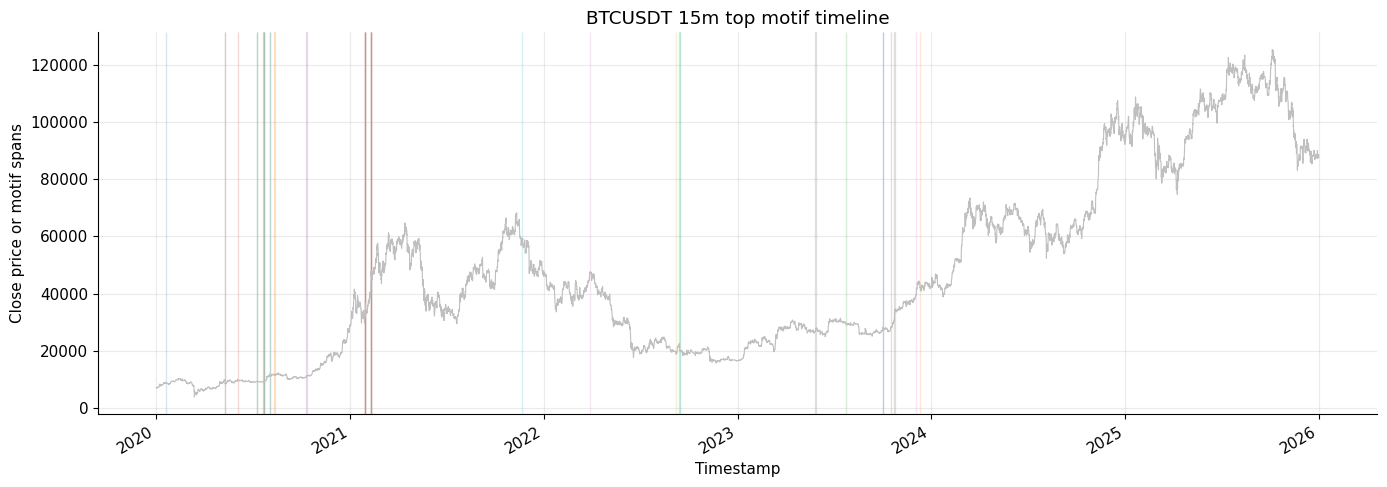

Loaded ETHUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_ETHUSDT_15m_top_motifs.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_ETHUSDT_15m_top_motifs.pdf


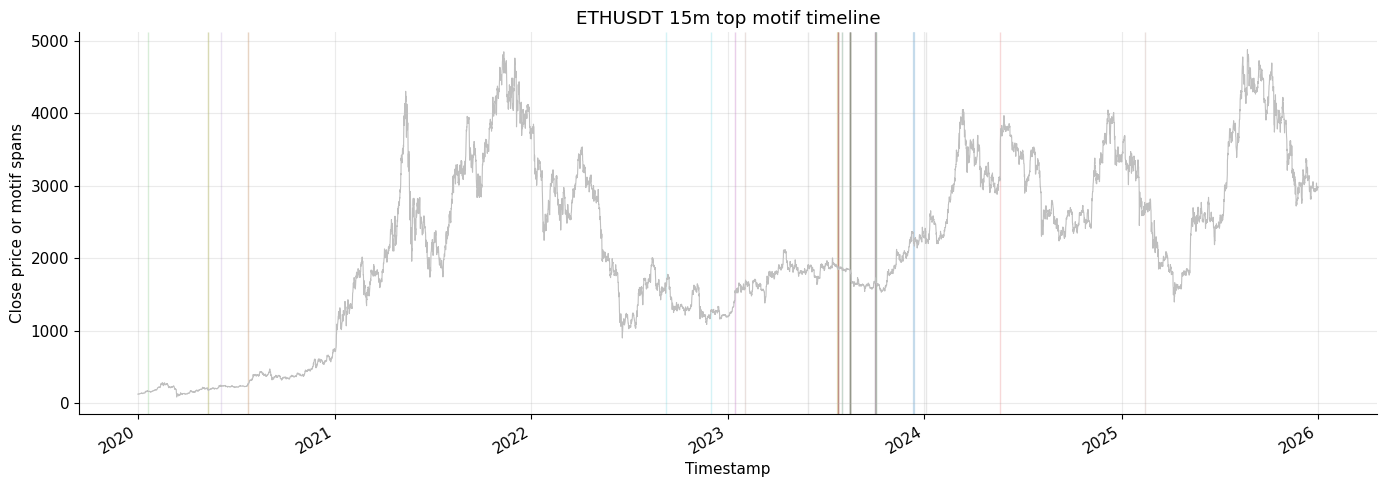

Loaded BTCUSDT_1h_features_2020_2025.parquet: 52,577 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_1h_top_motifs.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_1h_top_motifs.pdf


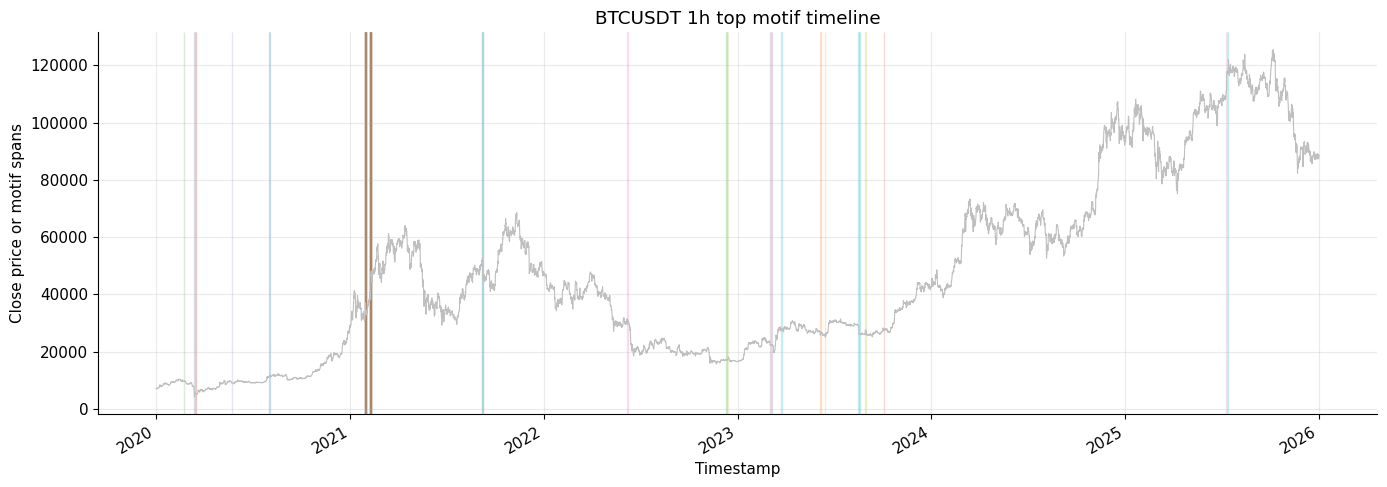

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_15m_high_vol_top_motifs.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/matrix_profile/study_mp_timeline_BTCUSDT_15m_high_vol_top_motifs.pdf


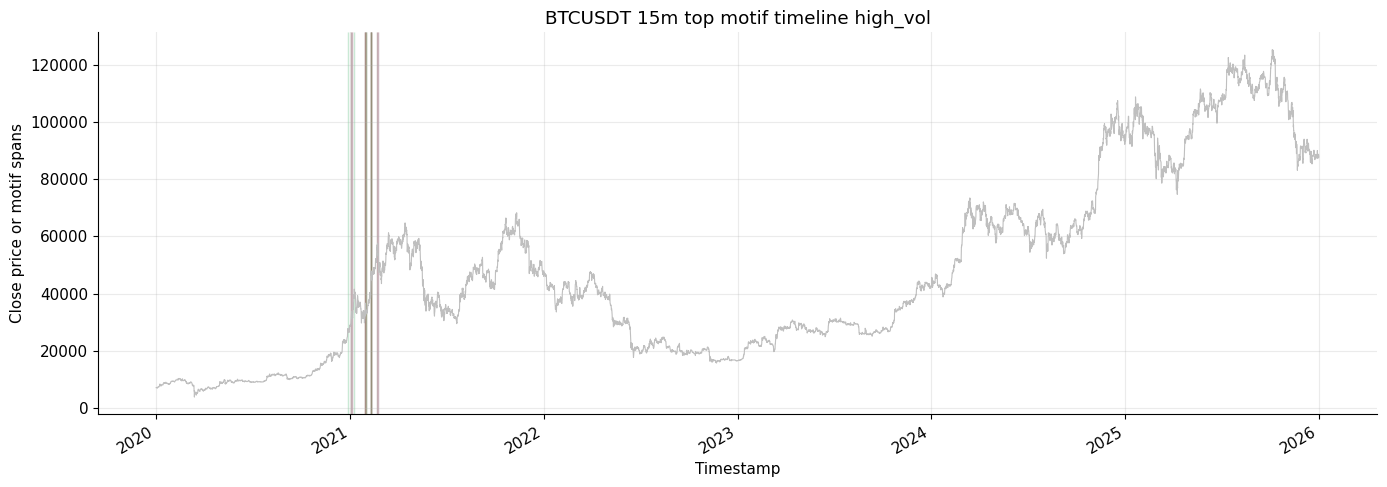

In [10]:
def overlap_table(df, n=50):
    if df.empty:
        return pd.DataFrame()
    rows = []
    for i, row in df.head(n).iterrows():
        w = int(row.get("window_length", 0)) if pd.notna(row.get("window_length", np.nan)) else 0
        s1 = int(row.get("motif_start_1", -1)) if pd.notna(row.get("motif_start_1", np.nan)) else -1
        s2 = int(row.get("motif_start_2", -1)) if pd.notna(row.get("motif_start_2", np.nan)) else -1
        if w <= 0 or s1 < 0 or s2 < 0:
            continue
        a1, a2 = s1, s1 + w
        b1, b2 = s2, s2 + w
        overlap_len = max(0, min(a2, b2) - max(a1, b1))
        rows.append({
            "motif_id": i,
            "asset": row.get("asset"),
            "frequency": row.get("frequency"),
            "mode": row.get("mode"),
            "regime_label": row.get("regime_label"),
            "window_length": w,
            "start_1": s1,
            "start_2": s2,
            "overlap_length": overlap_len,
            "overlap_ratio": overlap_len / w if w else np.nan,
        })
    return pd.DataFrame(rows)

mp_top50 = mp.sort_values(distance_col, ascending=True).head(50) if distance_col else mp.head(50)
overlaps = overlap_table(mp_top50)
display_table(overlaps, 20)
save_table(overlaps, "study_mp_top50_motif_window_overlap")

def plot_motif_timeline(df, asset, frequency, filename, title_extra=""):
    subset = filter_scope(df, asset, frequency)
    if subset.empty:
        print(f"No motif rows for timeline: {asset} {frequency}")
        return
    if distance_col:
        subset = subset.sort_values(distance_col, ascending=True).head(20)
    feature = load_feature_data(asset, frequency)
    ts = timestamp_column(feature)
    fig, ax = plt.subplots(figsize=(14, 5))
    if not feature.empty and ts and "close" in feature.columns:
        sampled = feature[[ts, "close"]].dropna().sort_values(ts)
        if len(sampled) > 8000:
            sampled = sampled.iloc[:: int(np.ceil(len(sampled) / 8000))]
        ax.plot(sampled[ts], sampled["close"], color="0.75", linewidth=0.8, label="close")
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for j, (_, row) in enumerate(subset.iterrows()):
        w = int(row.get("window_length", 1)) if pd.notna(row.get("window_length", np.nan)) else 1
        for start_col, time_col in [("motif_start_1", "motif_timestamp_1"), ("motif_start_2", "motif_timestamp_2")]:
            start_time = row.get(time_col)
            if pd.isna(start_time) and not feature.empty and ts and pd.notna(row.get(start_col, np.nan)):
                idx = int(row[start_col])
                if 0 <= idx < len(feature):
                    start_time = feature.iloc[idx][ts]
            if pd.notna(start_time):
                start_time = pd.to_datetime(start_time)
                end_time = start_time + pd.Timedelta(minutes=15 * w if frequency == "15m" else 60 * w)
                ax.axvspan(start_time, end_time, color=colors[j % len(colors)], alpha=0.18)
    ax.set_title(f"{asset} {frequency} top motif timeline {title_extra}".strip())
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Close price or motif spans")
    fig.autofmt_xdate()
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["matrix_profile"])
    plt.show()

plot_motif_timeline(mp, "BTCUSDT", "15m", "study_mp_timeline_BTCUSDT_15m_top_motifs")
plot_motif_timeline(mp, "ETHUSDT", "15m", "study_mp_timeline_ETHUSDT_15m_top_motifs")
plot_motif_timeline(mp, "BTCUSDT", "1h", "study_mp_timeline_BTCUSDT_1h_top_motifs")
if "regime_label" in mp.columns:
    plot_motif_timeline(mp[mp["regime_label"].astype(str).eq("high_vol")], "BTCUSDT", "15m", "study_mp_timeline_BTCUSDT_15m_high_vol_top_motifs", "high_vol")


## Agnostic vs Conditioned Evidence


In [11]:
def mode_metrics(df, mode):
    part = df[df["mode"].astype(str).eq(mode)] if "mode" in df.columns else pd.DataFrame()
    values = pd.to_numeric(part[distance_col], errors="coerce").dropna() if distance_col and not part.empty else pd.Series(dtype=float)
    return {
        "saved motif rows": len(part),
        "median distance": values.median() if len(values) else np.nan,
        "q10 distance": values.quantile(0.10) if len(values) else np.nan,
        "best distance": values.min() if len(values) else np.nan,
        "number of regimes represented": part["regime_label"].nunique(dropna=True) if "regime_label" in part.columns else np.nan,
        "number of windows represented": part["window_length"].nunique(dropna=True) if "window_length" in part.columns else np.nan,
        "number of feature sets represented": part["feature_set"].nunique(dropna=True) if "feature_set" in part.columns else np.nan,
        "runtime if available": part["runtime_seconds"].sum() if "runtime_seconds" in part.columns else np.nan,
        "figure examples available": "generated above when feature windows align",
    }

agnostic = mode_metrics(mp, "agnostic")
conditioned = mode_metrics(mp, "conditioned")
interpretations = {
    "saved motif rows": "Conditioned row counts are expected to be larger when searches are repeated across regimes, methods, and segments.",
    "median distance": "Lower values indicate closer motif-neighbour pairs within the saved results.",
    "q10 distance": "Lower top-decile distances indicate stronger best-candidate similarity.",
    "best distance": "Best observed saved motif distance.",
    "number of regimes represented": "Conditioned discovery attaches motifs to market states.",
    "number of windows represented": "Window-length coverage in the saved benchmark.",
    "number of feature sets represented": "Feature coverage in the saved benchmark.",
    "runtime if available": "Runtime is read from saved result rows when present.",
    "figure examples available": "Visual support depends on available feature data and start indices.",
}
comparison_rows = []
for metric in agnostic:
    comparison_rows.append({
        "Metric": metric,
        "Agnostic": agnostic[metric],
        "Conditioned": conditioned[metric],
        "Interpretation": interpretations.get(metric, ""),
    })
mode_comparison = pd.DataFrame(comparison_rows)
display_table(mode_comparison, 20)
save_table(mode_comparison, "study_mp_agnostic_vs_conditioned_evidence")


,Metric,Agnostic,Conditioned,Interpretation
0,saved motif rows,720,81267,Conditioned row counts are expected to be larg...
1,median distance,1.89083,4.66611,Lower values indicate closer motif-neighbour p...
2,q10 distance,0.373395,1.381849,Lower top-decile distances indicate stronger b...
3,best distance,0.081861,0.159237,Best observed saved motif distance.
4,number of regimes represented,1,3,Conditioned discovery attaches motifs to marke...
5,number of windows represented,9,9,Window-length coverage in the saved benchmark.
6,number of feature sets represented,4,4,Feature coverage in the saved benchmark.
7,runtime if available,706668.274338,14508.260073,Runtime is read from saved result rows when pr...
8,figure examples available,generated above when feature windows align,generated above when feature windows align,Visual support depends on available feature da...


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_agnostic_vs_conditioned_evidence.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_agnostic_vs_conditioned_evidence.csv')

### Interpretation
Conditioned discovery increases regime-specific interpretability by attaching motif candidates to market states. Row counts are larger because the search is repeated across regimes, regime methods, and segments.


## Evaluation Metrics


In [12]:
display_table(eval_df, 20)
save_table(eval_df, "study_mp_evaluation_raw")

numeric_metrics = [c for c in eval_df.columns if pd.api.types.is_numeric_dtype(eval_df[c])]
group_sets = [
    ["mode"],
    ["asset", "frequency", "mode"],
    ["regime_label"],
    ["window_length"],
    ["feature_set"],
    ["profile_type"],
]
for group_cols in group_sets:
    existing = [c for c in group_cols if c in eval_df.columns]
    if eval_df.empty or not existing or not numeric_metrics:
        continue
    summary = eval_df.groupby(existing, dropna=False)[numeric_metrics].agg(["mean", "median", "min", "max"])
    summary.columns = ["_".join(col).strip("_") for col in summary.columns.to_flat_index()]
    summary = summary.reset_index()
    name = "study_mp_evaluation_by_" + "_".join(existing)
    display_table(summary, 20)
    save_table(summary, name)


,asset,frequency,method,mode,regime_method,regime_label,window_length,feature_set,number_of_motifs,mean_motif_distance_or_score,median_motif_distance,recurrence_count,runtime_seconds,time_split_stability,cross_regime_overlap,notes
0,BTCUSDT,15m,matrix_profile,agnostic,none,all,32,close,10,0.596049,0.603702,20,234.763122,0.428571,0.6,Matrix Profile motif pairs; recurrence count t...
1,BTCUSDT,15m,matrix_profile,agnostic,none,all,32,log_return,10,1.585391,1.530427,20,71.766893,0.428571,0.3,Matrix Profile motif pairs; recurrence count t...
2,BTCUSDT,15m,matrix_profile,agnostic,none,all,32,"log_return,abs_log_return,rolling_volatility_6...",10,1.435926,1.447333,20,82187.743148,0.666667,0.3,Matrix Profile motif pairs; recurrence count t...
3,BTCUSDT,15m,matrix_profile,agnostic,none,all,32,rolling_volatility_60,10,0.126718,0.128299,20,72.998220,1.000000,0.5,Matrix Profile motif pairs; recurrence count t...
4,BTCUSDT,15m,matrix_profile,agnostic,none,all,64,close,10,0.983515,0.983485,20,75.421325,0.428571,0.6,Matrix Profile motif pairs; recurrence count t...
5,BTCUSDT,15m,matrix_profile,agnostic,none,all,64,log_return,10,3.410756,3.529147,20,79.883024,0.666667,0.0,Matrix Profile motif pairs; recurrence count t...
6,BTCUSDT,15m,matrix_profile,agnostic,none,all,64,"log_return,abs_log_return,rolling_volatility_6...",10,2.802269,2.850943,20,83244.498304,0.666667,0.3,Matrix Profile motif pairs; recurrence count t...
7,BTCUSDT,15m,matrix_profile,agnostic,none,all,64,rolling_volatility_60,10,0.311857,0.319271,20,74.501712,0.666667,0.3,Matrix Profile motif pairs; recurrence count t...
8,BTCUSDT,15m,matrix_profile,agnostic,none,all,128,close,10,1.545626,1.589199,20,78.740880,0.250000,0.6,Matrix Profile motif pairs; recurrence count t...
9,BTCUSDT,15m,matrix_profile,agnostic,none,all,128,log_return,10,6.478711,6.627243,20,74.817206,1.000000,0.3,Matrix Profile motif pairs; recurrence count t...


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_evaluation_raw.csv


,mode,window_length_mean,window_length_median,window_length_min,window_length_max,number_of_motifs_mean,number_of_motifs_median,number_of_motifs_min,number_of_motifs_max,mean_motif_distance_or_score_mean,...,runtime_seconds_min,runtime_seconds_max,time_split_stability_mean,time_split_stability_median,time_split_stability_min,time_split_stability_max,cross_regime_overlap_mean,cross_regime_overlap_median,cross_regime_overlap_min,cross_regime_overlap_max
0,agnostic,125.333333,72.0,24,336,10.000000,10.0,10,10,3.821333,...,6.505330,85043.874516,0.615465,0.666667,0.111111,1.0,0.363889,0.4,0.0,0.6
1,conditioned,125.268293,72.0,24,336,61.941311,32.0,1,369,8.064967,...,0.005902,290.351911,0.527119,0.500000,0.000000,1.0,0.000000,0.0,0.0,0.0


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_evaluation_by_mode.csv


,asset,frequency,mode,window_length_mean,window_length_median,window_length_min,window_length_max,number_of_motifs_mean,number_of_motifs_median,number_of_motifs_min,...,runtime_seconds_min,runtime_seconds_max,time_split_stability_mean,time_split_stability_median,time_split_stability_min,time_split_stability_max,cross_regime_overlap_mean,cross_regime_overlap_median,cross_regime_overlap_min,cross_regime_overlap_max
0,BTCUSDT,15m,agnostic,120.0,96.0,32,256,10.000000,10.0,10,...,71.766893,85043.874516,0.607887,0.666667,0.250000,1.0,0.35625,0.30,0.0,0.6
1,BTCUSDT,15m,conditioned,120.0,96.0,32,256,106.364583,73.5,10,...,0.117481,290.351911,0.449900,0.395788,0.084746,1.0,0.00000,0.00,0.0,0.0
2,BTCUSDT,1h,agnostic,129.6,72.0,24,336,10.000000,10.0,10,...,6.609279,5177.575290,0.665476,0.666667,0.250000,1.0,0.36500,0.40,0.1,0.6
3,BTCUSDT,1h,conditioned,129.6,72.0,24,336,24.758333,20.0,1,...,0.005973,41.425975,0.693306,0.703297,0.000000,1.0,0.00000,0.00,0.0,0.0
4,ETHUSDT,15m,agnostic,120.0,96.0,32,256,10.000000,10.0,10,...,66.129792,81329.213244,0.601438,0.666667,0.111111,1.0,0.32500,0.35,0.1,0.6
5,ETHUSDT,15m,conditioned,120.0,96.0,32,256,112.075658,76.0,1,...,0.005902,221.012255,0.372446,0.362755,0.000000,1.0,0.00000,0.00,0.0,0.0
6,ETHUSDT,1h,agnostic,129.6,72.0,24,336,10.000000,10.0,10,...,6.505330,4891.305967,0.582738,0.666667,0.250000,1.0,0.40000,0.40,0.1,0.6
7,ETHUSDT,1h,conditioned,129.6,72.0,24,336,21.250000,17.0,1,...,0.006079,28.968040,0.553320,0.500000,0.000000,1.0,0.00000,0.00,0.0,0.0


...

Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_evaluation_by_regime_label.csv


,window_length,window_length_mean,window_length_median,window_length_min,window_length_max,number_of_motifs_mean,number_of_motifs_median,number_of_motifs_min,number_of_motifs_max,mean_motif_distance_or_score_mean,...,runtime_seconds_min,runtime_seconds_max,time_split_stability_mean,time_split_stability_median,time_split_stability_min,time_split_stability_max,cross_regime_overlap_mean,cross_regime_overlap_median,cross_regime_overlap_min,cross_regime_overlap_max
0,24,24.0,24.0,24,24,38.421053,30.0,10,90,2.334209,...,0.160621,5050.272174,0.693083,0.500000,0.166667,1.0,0.017105,0.0,0.0,0.5
1,32,32.0,32.0,32,32,176.480769,138.0,10,369,3.139843,...,0.074507,82187.743148,0.441245,0.372549,0.111111,1.0,0.016667,0.0,0.0,0.6
2,48,48.0,48.0,48,48,32.953947,24.0,10,81,4.369017,...,0.132075,4985.327335,0.643042,0.666667,0.120000,1.0,0.019079,0.0,0.0,0.6
3,64,64.0,64.0,64,64,128.230769,104.0,5,266,5.295272,...,0.044107,83244.498304,0.406977,0.385542,0.130682,1.0,0.014744,0.0,0.0,0.6
4,72,72.0,72.0,72,72,25.019737,17.0,10,61,5.835828,...,0.083671,5140.384018,0.589950,0.604348,0.095238,1.0,0.018421,0.0,0.0,0.5
5,128,128.0,128.0,128,128,75.897436,63.0,3,155,8.459644,...,0.020074,84879.682271,0.434070,0.400000,0.080645,1.0,0.017308,0.0,0.0,0.6
6,168,168.0,168.0,168,168,11.065789,8.0,4,24,10.352227,...,0.028866,5058.466830,0.567133,0.500000,0.055556,1.0,0.023026,0.0,0.0,0.6
7,256,256.0,256.0,256,256,36.211538,31.5,1,77,13.757870,...,0.005902,85043.874516,0.398118,0.384615,0.000000,1.0,0.021154,0.0,0.0,0.6
8,336,336.0,336.0,336,336,4.138158,3.0,1,10,17.072948,...,0.005973,5177.575290,0.623567,0.666667,0.000000,1.0,0.023026,0.0,0.0,0.6


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_evaluation_by_window_length.csv


,feature_set,window_length_mean,window_length_median,window_length_min,window_length_max,number_of_motifs_mean,number_of_motifs_median,number_of_motifs_min,number_of_motifs_max,mean_motif_distance_or_score_mean,...,runtime_seconds_min,runtime_seconds_max,time_split_stability_mean,time_split_stability_median,time_split_stability_min,time_split_stability_max,cross_regime_overlap_mean,cross_regime_overlap_median,cross_regime_overlap_min,cross_regime_overlap_max
0,close,125.271676,72.0,24,336,59.580925,30.0,1,366,5.750884,...,0.006010,234.763122,0.528739,0.5,0.0,1.0,0.022254,0.0,0.0,0.6
1,log_return,125.271676,72.0,24,336,59.621387,30.0,1,369,11.209914,...,0.005902,79.883024,0.521550,0.5,0.0,1.0,0.017919,0.0,0.0,0.6
2,"log_return,abs_log_return,rolling_volatility_6...",125.271676,72.0,24,336,58.546243,30.0,1,366,9.974377,...,0.165801,85043.874516,0.537864,0.5,0.0,1.0,0.018786,0.0,0.0,0.5
3,rolling_volatility_60,125.271676,72.0,24,336,59.208092,30.0,1,366,4.441625,...,0.006022,79.985376,0.538707,0.5,0.0,1.0,0.016763,0.0,0.0,0.5


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_evaluation_by_feature_set.csv


## Runtime and CPU/GPU Audit


In [13]:
display_table(runtime, 20)
save_table(runtime, "study_mp_runtime_raw")
for group_cols in [["asset", "frequency", "mode", "profile_type"], ["window_length"], ["profile_type"]]:
    existing = [c for c in group_cols if c in runtime.columns]
    if runtime.empty or "runtime_seconds" not in runtime.columns or not existing:
        continue
    out = runtime.groupby(existing, dropna=False)["runtime_seconds"].agg(["count", "sum", "mean", "median", "min", "max"]).reset_index()
    display_table(out, 20)
    save_table(out, "study_mp_runtime_by_" + "_".join(existing))

if "used_gpu" in mp.columns:
    gpu_audit = mp["used_gpu"].value_counts(dropna=False).rename_axis("used_gpu").reset_index(name="rows")
    display_table(gpu_audit)
    save_table(gpu_audit, "study_mp_gpu_audit")
    if len(gpu_audit) and gpu_audit["used_gpu"].astype(str).str.lower().isin(["false", "0"]).all():
        print("All reported Matrix Profile results were generated using CPU execution. GPU acceleration was allowed by the pipeline but was not used in the executed run.")
else:
    print("No used_gpu column is available in Matrix Profile motif results.")


,asset,frequency,mode,regime_method,window_length,profile_type,runtime_seconds
0,BTCUSDT,15m,agnostic,none,32,multivariate,82187.743148
1,BTCUSDT,15m,agnostic,none,32,univariate,379.528234
2,BTCUSDT,15m,agnostic,none,64,multivariate,83244.498304
3,BTCUSDT,15m,agnostic,none,64,univariate,229.806061
4,BTCUSDT,15m,agnostic,none,128,multivariate,84879.682271
5,BTCUSDT,15m,agnostic,none,128,univariate,230.873110
6,BTCUSDT,15m,agnostic,none,256,multivariate,85043.874516
7,BTCUSDT,15m,agnostic,none,256,univariate,233.952696
8,BTCUSDT,15m,conditioned,quantile_2_rolling_240,32,multivariate,456.269934
9,BTCUSDT,15m,conditioned,quantile_2_rolling_240,32,univariate,20.406469


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_runtime_raw.csv


,asset,frequency,mode,profile_type,count,sum,mean,median,min,max
0,BTCUSDT,15m,agnostic,multivariate,4,335355.798239,83838.949560,84062.090287,82187.743148,85043.874516
1,BTCUSDT,15m,agnostic,univariate,4,1074.160100,268.540025,232.412903,229.806061,379.528234
2,BTCUSDT,15m,conditioned,multivariate,36,6079.915020,168.886528,111.076230,21.363121,459.005580
3,BTCUSDT,15m,conditioned,univariate,36,267.341016,7.426139,5.588792,1.174789,20.406469
4,BTCUSDT,1h,agnostic,multivariate,5,25412.025647,5082.405129,5058.466830,4985.327335,5177.575290
5,BTCUSDT,1h,agnostic,univariate,5,112.223162,22.444632,22.582700,20.517229,24.303688
6,BTCUSDT,1h,conditioned,multivariate,45,1154.660920,25.659132,17.863804,1.135438,75.300674
7,BTCUSDT,1h,conditioned,univariate,45,68.985770,1.533017,1.259606,0.075213,5.535748
8,ETHUSDT,15m,agnostic,multivariate,4,319502.657328,79875.664332,80211.079481,77751.285121,81329.213244
9,ETHUSDT,15m,agnostic,univariate,4,843.275701,210.818925,210.307503,202.779174,219.881521


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_runtime_by_asset_frequency_mode_profile_type.csv


,window_length,count,sum,mean,median,min,max
0,24,40,10655.365711,266.384143,14.589103,1.159122,5050.272174
1,32,42,168535.371547,4012.746942,88.389824,0.227968,82187.743148
2,48,40,10475.543922,261.888598,11.601180,0.906728,4985.327335
3,64,42,168320.874484,4007.639869,73.131668,0.147735,83244.498304
4,72,40,10517.984733,262.949618,6.764897,0.597019,5140.384018
5,128,42,167604.712825,3990.588401,49.113421,0.061346,84879.682271
6,168,40,10144.699058,253.617476,2.169682,0.203168,5058.466830
7,256,42,164781.144595,3923.360586,21.415959,0.017934,85043.874516
8,336,40,10140.837537,253.520938,0.644537,0.054368,5177.575290


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_runtime_by_window_length.csv


,profile_type,count,sum,mean,median,min,max
0,multivariate,184,718358.009481,3904.119617,50.079610,0.165801,85043.874516
1,univariate,184,2818.524930,15.318070,2.705693,0.017934,379.528234


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_runtime_by_profile_type.csv


,used_gpu,rows
0,False,81987


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_mp_gpu_audit.csv
All reported Matrix Profile results were generated using CPU execution. GPU acceleration was allowed by the pipeline but was not used in the executed run.


## Key findings
Use the generated top motif tables, threshold table, overlays, timelines, evaluation summaries, and runtime summaries to answer which Matrix Profile motifs were found and where the best distances occur.

## Thesis-safe interpretation
Matrix Profile found fixed-length motif candidates in the saved results when motif rows and distance columns are present. Lower distance values indicate stronger shape similarity under the selected feature and window length. Empirical thresholds are descriptive quantiles of the saved result distribution, not universal Matrix Profile constants.

## Limitations
This notebook does not rerun Matrix Profile and cannot recover missing motif windows, missing feature files, or empty profile tables. Agnostic and conditioned searches differ in scope, so row counts alone are not evidence of superiority.

## Recommended figures for thesis
- Distance distribution with empirical thresholds
- Top motif overlays for BTCUSDT 15m
- Top motif timelines for BTCUSDT 15m and ETHUSDT 15m
- Agnostic vs conditioned evidence table
- Runtime and CPU/GPU audit table
